In [1]:
import os,sys
sys.path.append(os.path.dirname(os.getcwd()))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
from functools import partial
from typing import Any, Sequence

# activate TPUs if available
try:
    import jax.tools.colab_tpu
    jax.tools.colab_tpu.setup_tpu()
except (KeyError, RuntimeError):
    print("TPU not found, continuing without it.")

from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import numpy as jnp
from jax import random
from jax import vmap
from jax.tree_util import Partial, tree_map

from jaxopt import LBFGS, GradientDescent
from jaxopt import linear_solve
from jaxopt import OptaxSolver
from jaxopt import tree_util

import optax

# we use flax to construct a small multi-layer perceptron
from flax import linen as nn
from tqdm.auto import tqdm

# for plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

TPU not found, continuing without it.


In [3]:
# import scienceplots
# plt.style.use(["science", "grid"])
%matplotlib inline

# Default setting
import matplotlib as mpl
import matplotlib
# import seaborn as sns
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
plt.rcParams['text.usetex'] = False
# mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

In [4]:
import jax.numpy as jnp
import jax
import pickle
import time
from jax import hessian, jacobian, jit, vmap, grad, random, value_and_grad
from functools import partial
import diffrax
from typing import Callable, Optional, Union
from flax import linen as nn
from flax.training.train_state import TrainState
import optax
from jax_md.quantity import force
import equinox as eqx
from tqdm import trange, tqdm

In [5]:
from blockymetamaterials.utils import SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_InputSource
from blockymetamaterials.energy import build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
from typing import Any, Literal, Optional, List, Union, Tuple, Dict
import dataclasses
from dataclasses import dataclass
from itertools import combinations
from cooptimization_real import setup_dynamic_solver, setup_dynamic_solver_all
from blockymetamaterials.plotting_input import generate_animation, generate_frames, plot_geometry, generate_patch_collection

In [6]:
color_list = ["#2980b9", "#e74c3c", "#00a043", "#793693", "#f1c40f","#fb9206","#54ada3"]

In [7]:
data_path = "Simulation/input_source_8_training_dataset.pkl"
with open(data_path, "rb") as f:
    data_dict = pickle.load(f)

output_data = data_dict["output_data"]
input_data = data_dict["input_data"]

print( jnp.max(jnp.max( input_data, axis=0),axis=0) )

[8.29534529e+02 3.31841730e+02 3.22879409e-01]


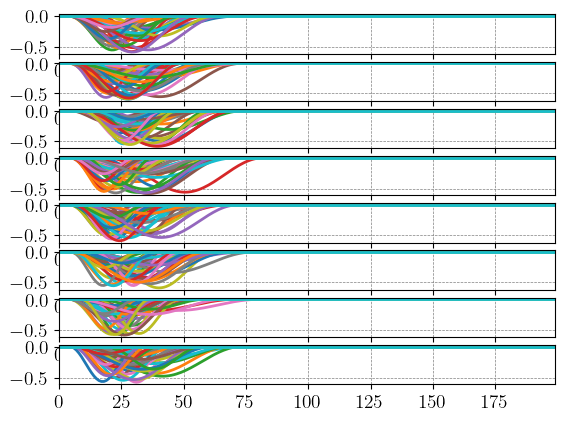

In [ ]:
n_source = 8
for i in range(len(output_data)):
    for k in range(n_source):
        plt.subplot(n_source,1,k+1)
        plt.plot(output_data[i][:,k])
plt.tight_layout()
plt.show()



## 1 Sensor

In [ ]:

n1_blocks = 5
n2_blocks = 4
n_source = 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = -25.0*jnp.pi/180
horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# Mechanical params
k_stretch = 4.00  # stretching stiffness 120. N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm

# NOTE: Damping is assumed to be the same for all blocks as it is small enough that the inertia change during optimization is negligible.
# The reference is taken to be zero angle rotated square geometry.
# 0.36125, 0.02175026 = mass and inertia of a single square of zero angle and unitary spacing and density and 0.15 bond length.

# Dynamic loading (default setting)
amplitude = jnp.ones((n1_blocks,)) * spacing  # 0.5 * spacing default 
loading_rate = 30.0 * jnp.ones((n1_blocks,))# jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_shift = 0
loaded_side = "top"
n_excited_blocks = n_source
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))

min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
bond_length = hinge_length
linearized_strains = True # change from False to True for linearized strains
use_contact = True
k_contact = k_rot

geometry = QuadGeometry_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_source=n_source
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant



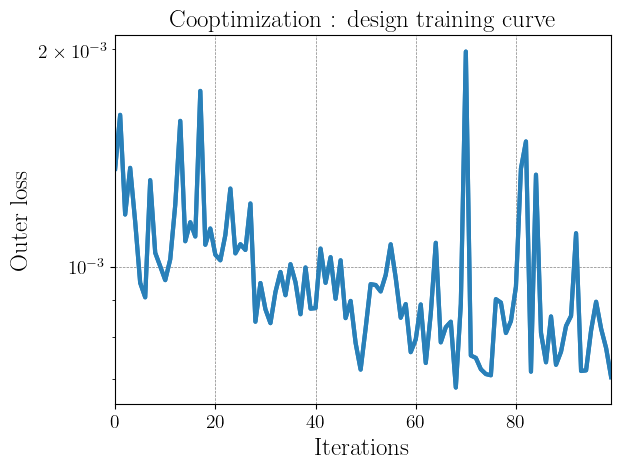

initial loss : 1.3653e-03
minimum loss : 6.8066e-04
minimum loss idx :  68


In [ ]:
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
with open("12082025_cooptimization_sim_1DCNN_data_300_n_source_2.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)

opt_idx = jnp.argmin(jnp.array(loss_record))
print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
print("minimum loss idx : ", opt_idx)

meta_params = param_record[opt_idx]
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
design_values = (horizontal_shifts, vertical_shifts)

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)
plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
# plt.legend()
plt.show()


In [64]:
from matplotlib import cm, colors
from blockymetamaterials.plotting_input import plot_multiple_geometries
# Example Usage
iter_num = len(loss_record)
geometry_data = []
# colors = ["#2980b9", "#e74c3c", "#2ecc71"]
cmap = cm.get_cmap("Spectral")
color_list = cmap( jnp.linspace(0.0, 1.0, iter_num) ) # extract 20 colors from cmap
norm = colors.Normalize(0, iter_num)

for i in range(iter_num):
    meta_params = param_record[i]
    horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
    design_values = (horizontal_shifts, vertical_shifts)

    geometry_data.append({
        "block_centroids": geometry.block_centroids(*design_values),
        "centroid_node_vectors": geometry.centroid_node_vectors(*design_values),
        "bond_connectivity": geometry.bond_connectivity(),
        "deformed": False
    })

/tmp/ipykernel_3830394/1996242423.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Spectral")


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


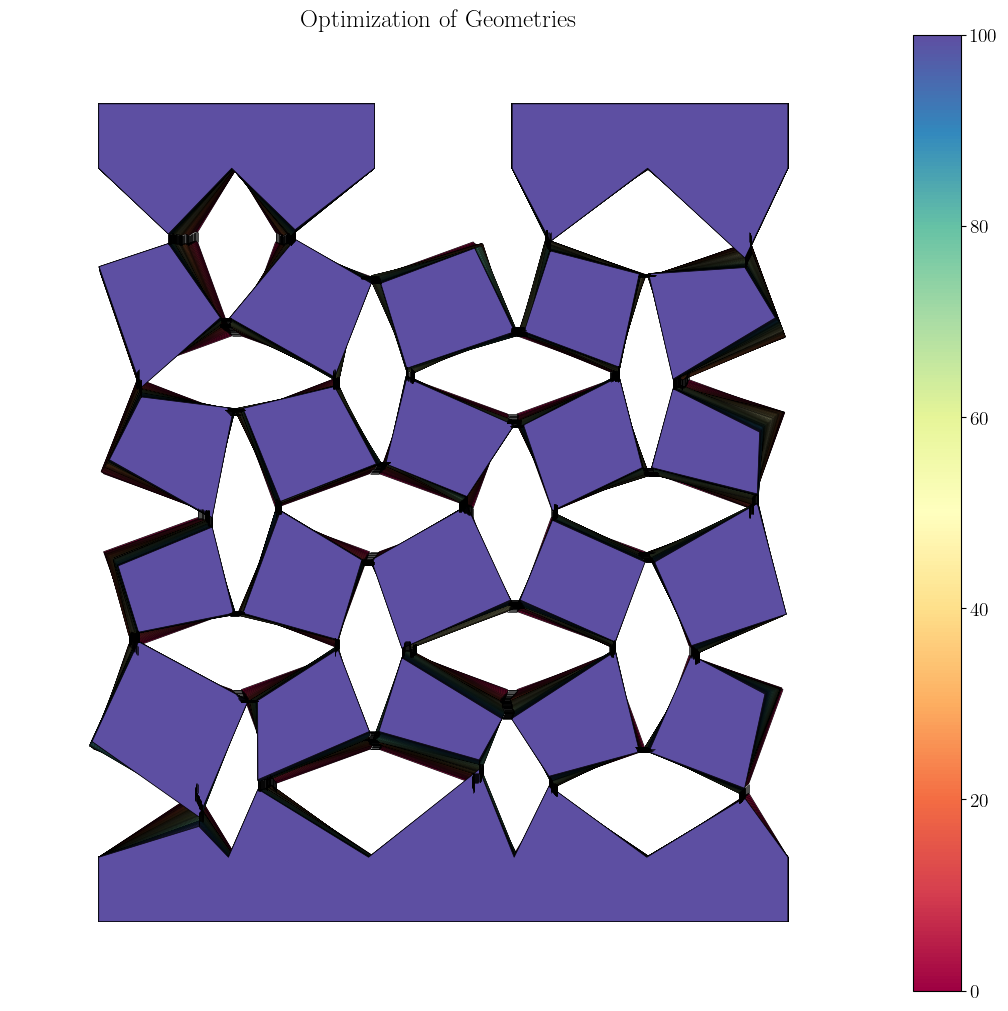

In [65]:
xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
# Plot all geometries in one figure
fig, ax = plot_multiple_geometries(geometry_data, figsize=(10, 10), colors=color_list, xlim=xlim, ylim=ylim)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.set_title("Optimization of Geometries")
ax.axis("off")
plt.show()

initial loss : 1.1607e-03
minimum loss : 4.4899e-04
minimum loss idx :  99


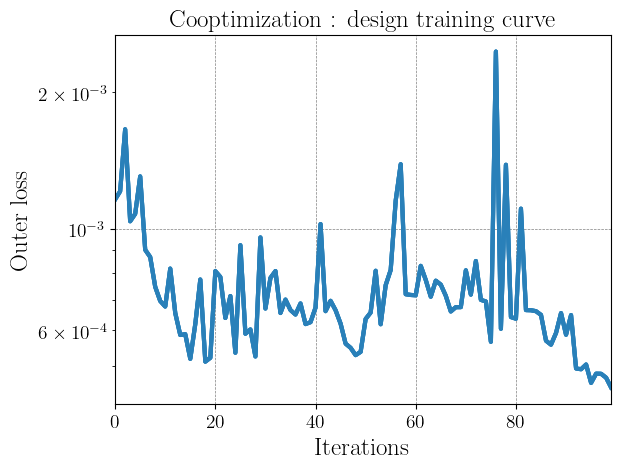

In [63]:
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
with open("01152026_cooptimization_sim_1DCNN_data_300_n_source_2_without_contact.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)

opt_idx = jnp.argmin(jnp.array(loss_record))
print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
print("minimum loss idx : ", opt_idx)

meta_params = param_record[opt_idx]
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
design_values = (horizontal_shifts, vertical_shifts)

plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)
plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
# plt.legend()
plt.show()

Data loaded from file.
(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)
training init loss : 1.2691e-03
test init loss : 1.3653e-03
training optimized loss : 5.6780e-04
test optimized loss : 6.8066e-04
TRAIN


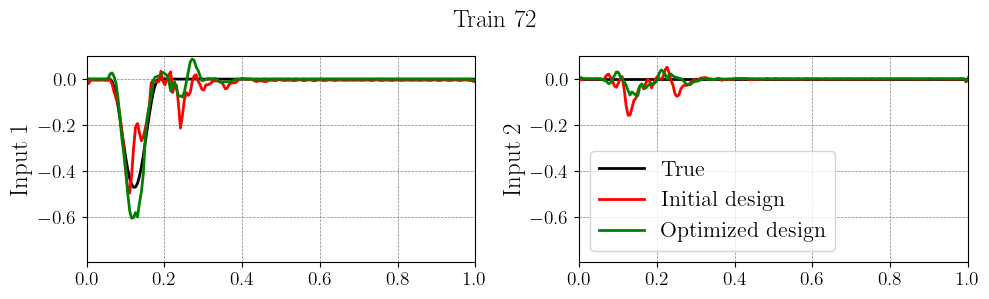

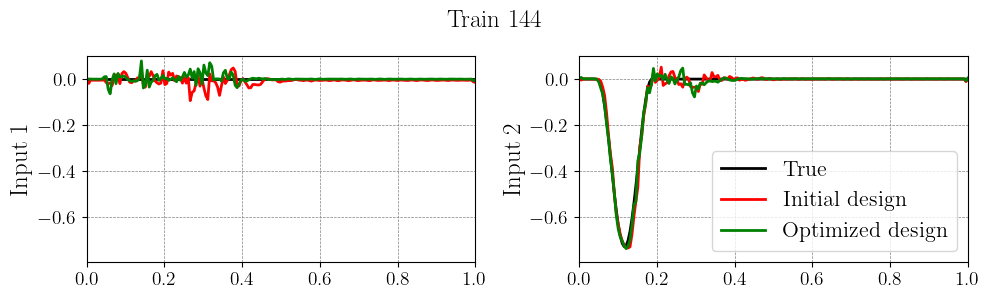

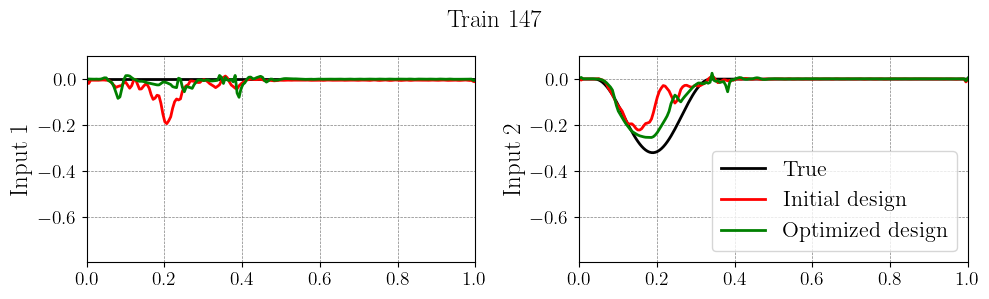

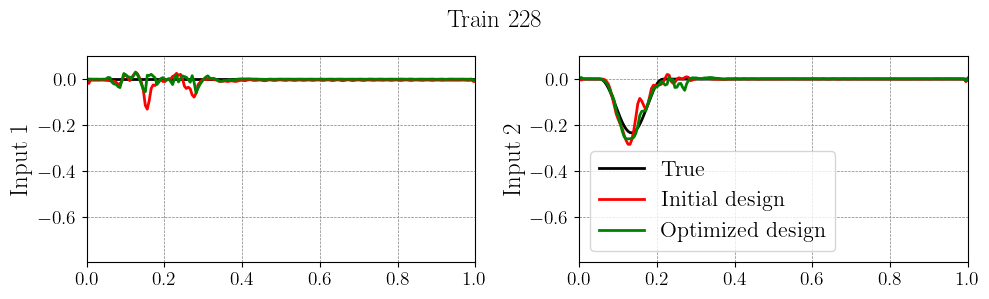

TEST


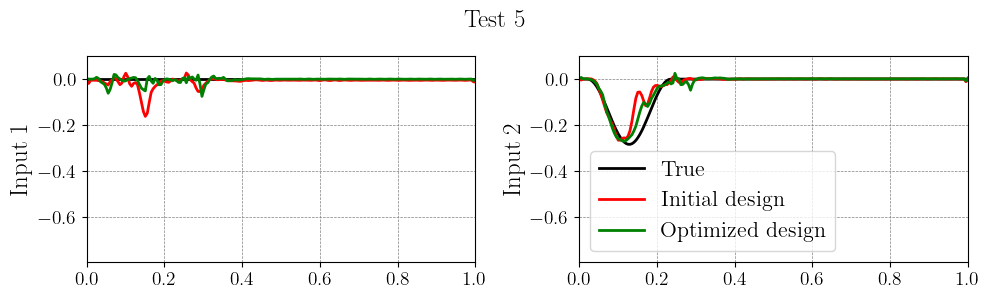

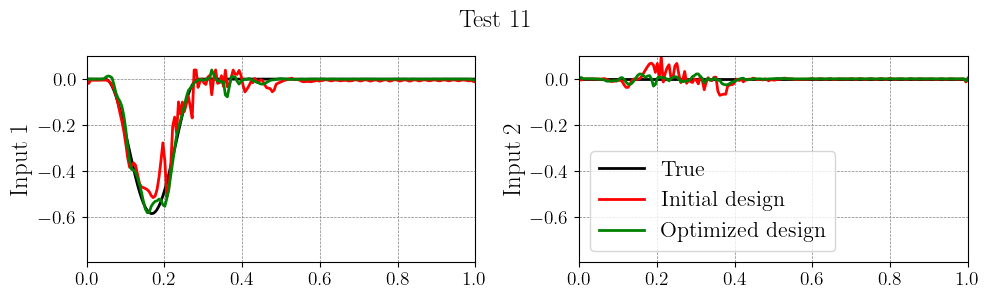

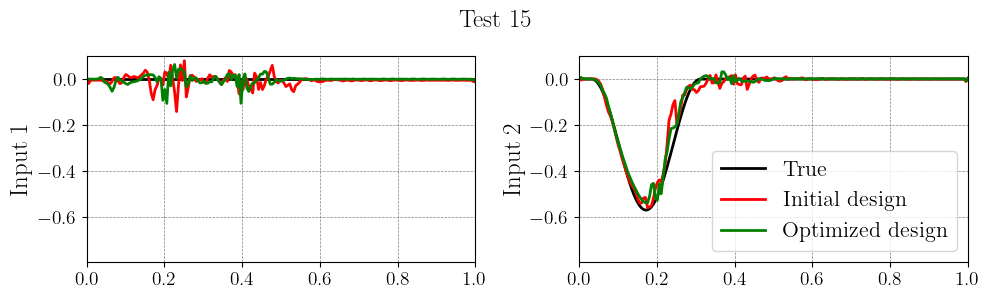

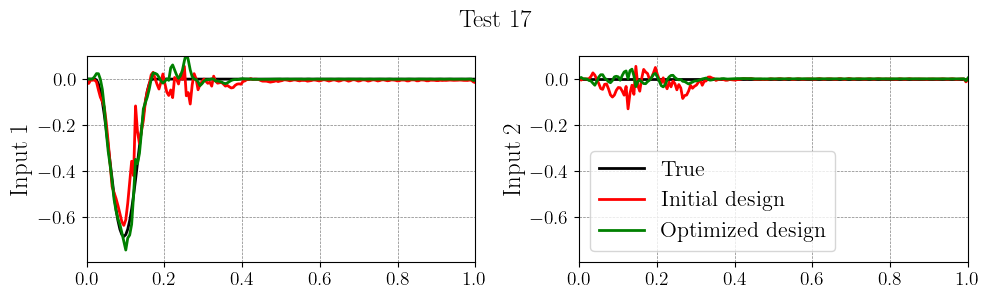

In [10]:
class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max
    
class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)

filename = f"Simulation/input_source_2_training_dataset.pkl"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
    input_data = data_dict["input_data"]
    output_data = data_dict["output_data"]
print("Data loaded from file.")

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]
test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_source)

# initial performance
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
in_param_sol = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y = model.apply(in_param_sol, train_data_normalized)
mse = jnp.mean((pred_y - train_output_normalized)**2)  
pred_y_test = model.apply(in_param_sol, test_data_normalized)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"training init loss : {mse:.4e}")
print(f"test init loss : {mse_test:.4e}")

in_param_sol = in_param_record[opt_idx][0]
training_input_data = in_param_record[opt_idx][2]
training_output_data = in_param_record[opt_idx][3]
test_input_data = in_param_record[opt_idx][4]
test_output_data = in_param_record[opt_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y_opt = model.apply(in_param_sol, train_data_normalized)
mse_opt = jnp.mean((pred_y_opt - train_output_normalized)**2)  
pred_y_test_opt = model.apply(in_param_sol, test_data_normalized)
mse_test_opt = jnp.mean((pred_y_test_opt - test_output_normalized)**2)
print(f"training optimized loss : {mse_opt:.4e}")
print(f"test optimized loss : {mse_test_opt:.4e}")

# original scale
_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_opt)

random_idx = jax.random.randint(key, shape=(4,), minval=0, maxval=training_input_data.shape[0]).sort()
random_idx_test = jax.random.randint(key, shape=(4,), minval=0, maxval=test_input_data.shape[0]).sort()
ts = jnp.linspace(0, simulation_time, n_timepoints)

min_value = jnp.min(mm_scaler.output_data_min)
print("TRAIN")
for i in random_idx:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, training_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.suptitle(f"Train {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()


_, pred_y_test_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test)
_, pred_y_test_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test_opt)

print("TEST")
for i in random_idx_test:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, test_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_test_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_test_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


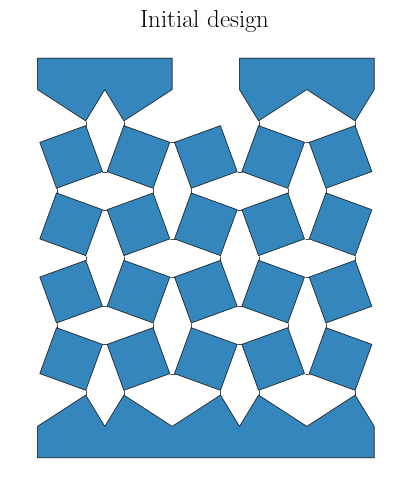

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


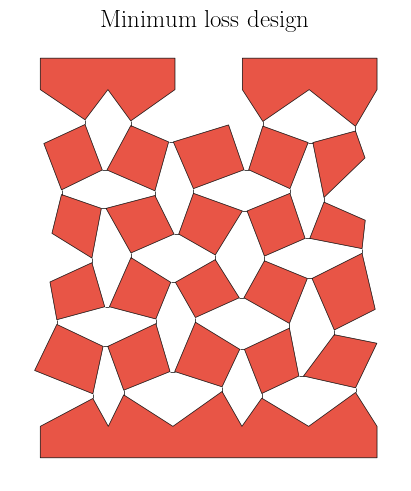

In [ ]:
from blockymetamaterials.plotting_input import plot_geometry



meta_params = param_record[0]
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
design_values = (horizontal_shifts, vertical_shifts)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
    color=color_list[0]
)
ax.axis("off")
# plt.title(f"Initial design")
plt.savefig(f"initial_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_n_source_{n_source}.svg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

meta_params = param_record[opt_idx]
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
design_values = (horizontal_shifts, vertical_shifts)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
    color=color_list[1]
)
ax.axis("off")
# plt.title(f"Minimum loss design")
plt.savefig(f"initial_design_n1_blocks_{n1_blocks}_n2_blocks_{n2_blocks}_n_source_{n_source}.svg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
plt.show()

## Input source 4

In [8]:

n1_blocks = 11
n2_blocks = 6
n_source = 4
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = -25.0*jnp.pi/180
horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# Mechanical params
k_stretch = 4.00  # stretching stiffness 120. N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm


min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
bond_length = hinge_length
linearized_strains = True # change from False to True for linearized strains
use_contact = True
k_contact = k_rot

geometry = QuadGeometry_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_source=n_source
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

design_values = (horizontal_shifts, vertical_shifts)


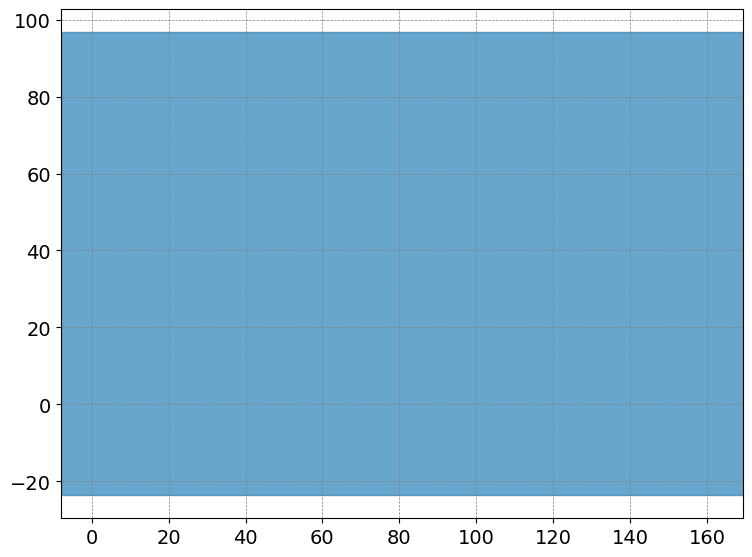

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

centroids = geometry.block_centroids(*design_values)
vectors = geometry.centroid_node_vectors(*design_values)

# Compute the last block's last point
last_block = centroids[-1] + vectors[-1]
last_point = last_block[-1]

# Compute the upper-right corner for the rectangle; 
# here let's assume the reference is the top-right block
top_block = centroids[-2] + vectors[-2]
top_point = top_block[-2]

width = top_point[0] - last_point[0]
height = top_point[1] - last_point[1]

fig, ax = plt.subplots(figsize=(4 * n1_blocks / 5, 6 * n2_blocks / 5))
rect = mpatches.Rectangle(
    (last_point[0], last_point[1]), width, height, color=color_list[0], alpha=0.7
)
ax.add_patch(rect)
ax.autoscale_view()
ax.set_aspect("equal")
plt.show()

In [ ]:
from blockymetamaterials.plotting_input import generate_patch_collection, generate_bond_collection, current_coordinates
from blockymetamaterials.geometry import compute_xy_limits
import matplotlib.patches as mpatches


centroids = geometry.block_centroids(*design_values)
vectors = geometry.centroid_node_vectors(*design_values)

# Compute the last block's last point
last_block = centroids[-1] + vectors[-1]
last_point = last_block[-1]

# Compute the upper-right corner for the rectangle; 
# here let's assume the reference is the top-right block
top_block = centroids[-2] + vectors[-2]
top_point = top_block[-2]

width = top_point[0] - last_point[0]
height = top_point[1] - last_point[1]

def plot_geometry(block_centroids, centroid_node_vectors, bond_connectivity, block_displacements=None, deformed=False,
                  color="#2980b9", figsize=None, xlim=None, ylim=None, ax=None):
    """
    docstring
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        ax.axis("equal")
    # Generate collection of blocks as polygons

    rect = mpatches.Rectangle(
        (last_point[0], last_point[1]), width, height, color=color[0])
    ax.add_patch(rect)
    patches = generate_patch_collection(block_centroids, centroid_node_vectors,
                                        block_displacements=block_displacements, deformed=deformed)
    patches.set(color=color)
    # patches.set(edgecolor="black", linewidth=0.5)
    ax.add_collection(patches)
    # Generate collection of bonds as lines
    # collection_bonds = generate_bond_collection(
    #     block_centroids, centroid_node_vectors, bond_connectivity, block_displacements=block_displacements, deformed=deformed)
    # ax.add_collection(collection_bonds)

    if deformed and block_displacements is not None:
        points = current_coordinates(centroid_node_vectors, block_centroids,
                                     block_displacements[:, -1], block_displacements[:, :2]).reshape((-1, 2))
    else:
        points = current_coordinates(centroid_node_vectors, block_centroids,
                                     jnp.zeros((len(centroid_node_vectors),)), jnp.zeros((len(centroid_node_vectors),2))).reshape((-1, 2))

    _xlim, _ylim = compute_xy_limits(points)
    xlim = _xlim if xlim is None else xlim
    ylim = _ylim if ylim is None else ylim
    ax.set(xlim=xlim, ylim=ylim)

    fig = ax.get_figure()

    return fig, ax

design_values = (horizontal_shifts, vertical_shifts)



configs = [
    ([(38,)],              ["01062026"], 0),
    ([(27,)],               ["01142026"], 0),
    ([(49,)],               ["01142026"], 0),
    ([(24,)],               ["01232026"], 0),
    ([(30,)],               ["01232026"], 0), # 1 sensor
    ([(25,29)],            ["01062026"], 1),
    ([(24,41)],             ["01162026"], 1),
    ([(35,30)],             ["01162026"], 1),
    ([(13,30)],             ["01232026"], 1),
    ([(19,35)],             ["01232026"], 1), # 2 sensors
    ([(25,29,38)],         ["01062026"], 2),
    ([(27,35,41)],          ["01162026"], 2),
    ([(24,30,38)],          ["01162026"], 2),
    ([(19,27,35)],          ["01232026"], 2),
    ([(13,27,41)],          ["01232026"], 2), # 3 sensors
    ([(26,28,35,41)],       ["01062026"], 3),
    ([(24,30,37,39)],       ["01162026"], 3),
    ([(26,28,41,46)],       ["01162026"], 3),
    ([(15,17,37,39)],       ["01262026"], 3),
    ([(25,29,47,51)],       ["01252026"], 3), # 4 sensors
    ([(25,29,34,38,42)],    ["01062026"], 4),
    ([(23,27,31,36,40)],    ["01162026"], 4),
    ([(23,25,27,29,31)],    ["01162026"], 4),
    ([(24,30,35,38,41)],    ["01252026"], 4),
    ([(13,27,30,39,46)],    ["01262026"], 4), # 5 sensors
    ([(13,16,19,35,38,41)], ["01062026"], 5),
    ([(24,27,30,36,39,42)], ["01162026"], 5),
    ([(24,27,30,47,50,53)], ["01162026"], 5),
    ([(14,18,25,29,36,40)], ["01252026"], 5),
    ([(25,29,36,40,47,51)], ["01252026"], 5) # 6 sensors
]

for config in configs:
    idx_set = config[0][0]
    if len(idx_set) == 1:
        file_idx = str(idx_set[0])
    else:
        file_idx = "_".join(str(x) for x in idx_set)

    colors = ["#6196ca" for j in range(geometry.n_blocks)]
    for j in idx_set:
        colors[j] = "k"

    xlim, ylim = geometry.get_xy_limits(
        *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
    fig, ax = plot_geometry(
        block_centroids=geometry.block_centroids(*design_values),
        centroid_node_vectors=geometry.centroid_node_vectors(
            *design_values),
        bond_connectivity=geometry.bond_connectivity(),
        xlim=xlim,
        ylim=ylim,
        figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
        color=colors
    )
    ax.axis("off")
    plt.savefig(f'Figure/4_input_source/4_input_source_idx_{file_idx}.eps', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


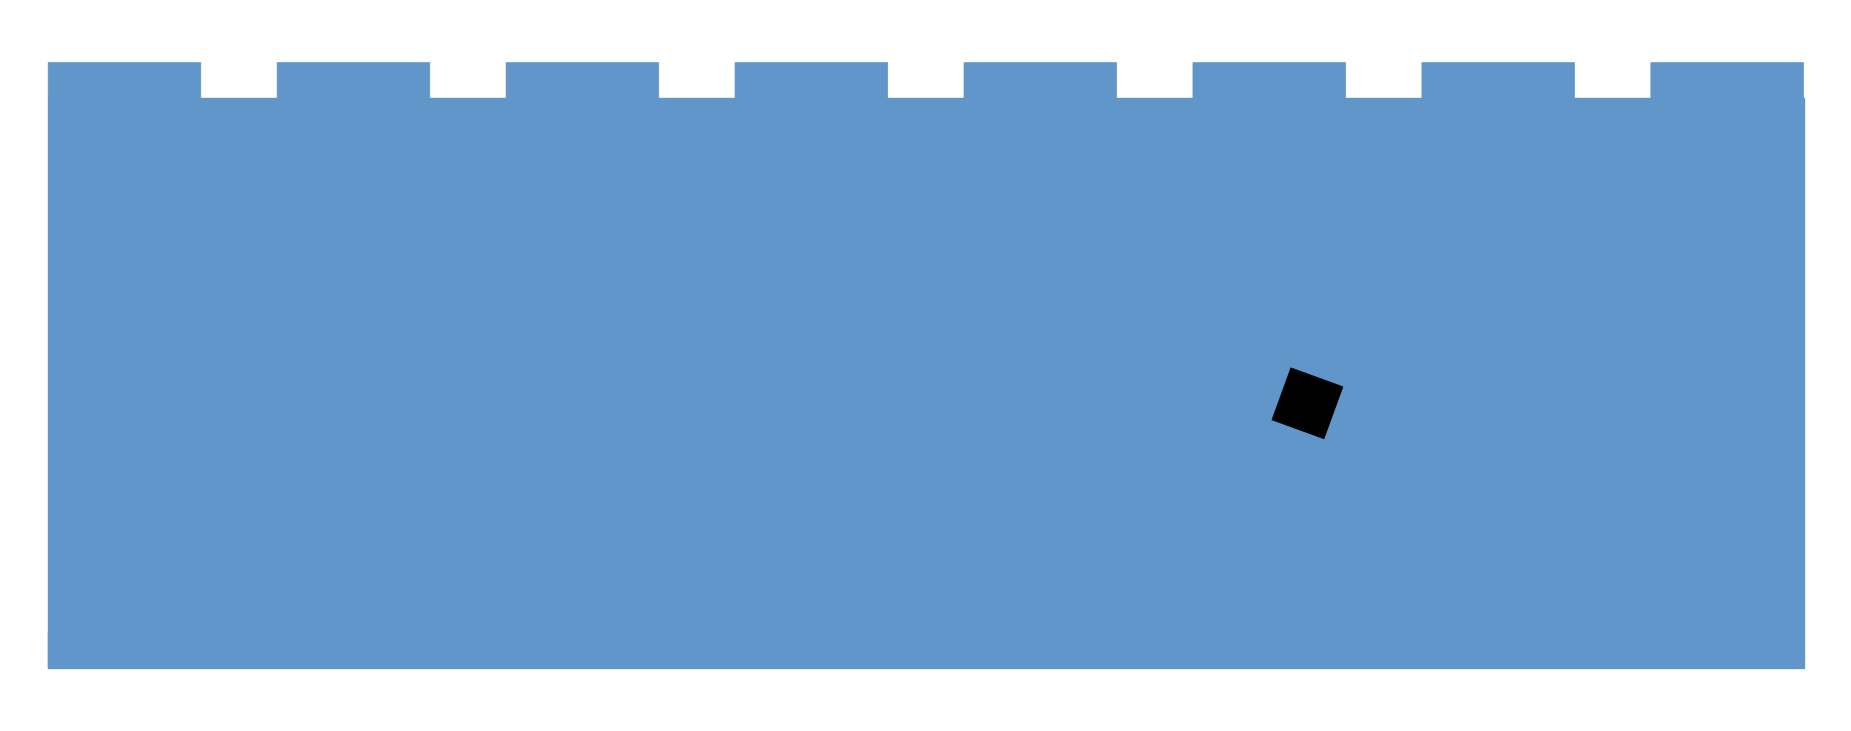

In [ ]:
configs = [
    ([(57,)],              ["01062026"], 0),
    ([(52,)],              ["01162026"], 0),
    ([(53,)],              ["01172026"], 0),
    ([(75,)],              ["01232026"], 0),
    ([(80,)],              ["01232026"], 0), # 1 sensor
    ([(52,62)],            ["01062026"], 1),
    ([(75,62)],            ["01172026"], 1),
    ([(75,85)],            ["01172026"], 1),
    ([(77,83)],            ["01232026"], 1),
    ([(60,77)],            ["01242026"], 1), # 2 sensors
    ([(52,57,62)],         ["01062026"], 2),
    ([(52,80,108)],         ["01172026"], 2),
    ([(57,75,85)],         ["01172026"], 2),
    ([(49,65,80)],         ["01242026"], 2),
    ([(75,80,85)],         ["01242026"], 2), # 3 sensors
    ([(49,55,60,65)],      ["01062026"], 3),
    ([(72,78,83,88)],      ["01182026"], 3),
    ([(55,60,75,85)],      ["01182026"], 3),
    ([(41,52,75,85)],      ["01242026"], 3),
    ([(41,52,77,83)],      ["01242026"], 3), # 4 sensors
    ([(49,53,57,61,65)],   ["01062026"], 4),
    ([(72,76,80,84,88)],   ["01162026"], 4),
    ([(49,57,65,76,84)],   ["01172026"], 4),
    ([(53,61,74,86,103)],   ["01252026"], 4),
    ([(53,57,61,74,86)],   ["01252026"], 4), # 5 sensors
    ([(28,34,40,97,103,109)], ["01072026"], 5),
    ([(49,56,63,97,104,111)], ["01172026"], 5),
    ([(49,54,59,63,98,106)], ["01172026"], 5),
    ([(51,55,59,63,79,84)], ["01242026"], 5),
    ([(52,57,62,74,86,103)], ["01242026"], 5)# 6 sensors
]

# configs = [
#     ([(62,)],              ["01162026"], 0),
# ]
block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

design_values = (horizontal_shifts, vertical_shifts)
centroids = geometry.block_centroids(*design_values)
vectors = geometry.centroid_node_vectors(*design_values)

# Compute the last block's last point
last_block = centroids[-1] + vectors[-1]
last_point = last_block[-1]

# Compute the upper-right corner for the rectangle; 
# here let's assume the reference is the top-right block
top_block = centroids[-2] + vectors[-2]
top_point = top_block[-2]

width = top_point[0] - last_point[0]
height = top_point[1] - last_point[1]

for config in configs:
    idx_set = config[0][0]
    if len(idx_set) == 1:
        file_idx = str(idx_set[0])
    else:
        file_idx = "_".join(str(x) for x in idx_set)

    colors = ["#6196ca" for j in range(geometry.n_blocks)]
    for j in idx_set:
        colors[j] = "k"

    xlim, ylim = geometry.get_xy_limits(
        *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
    fig, ax = plot_geometry(
        block_centroids=geometry.block_centroids(*design_values),
        centroid_node_vectors=geometry.centroid_node_vectors(
            *design_values),
        bond_connectivity=geometry.bond_connectivity(),
        xlim=xlim,
        ylim=ylim,
        figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
        color=colors
    )
    ax.axis("off")
    plt.savefig(f'Figure/8_input_source/8_input_source_idx_{file_idx}.eps', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    # break

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


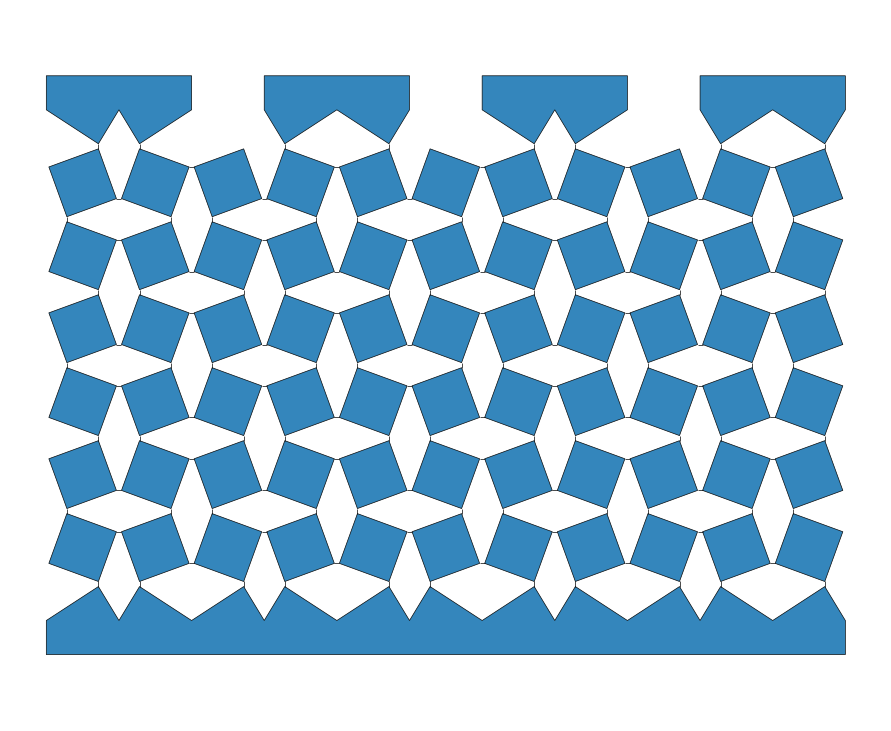

In [76]:
from blockymetamaterials.plotting_input import generate_animation, generate_frames, plot_geometry, generate_patch_collection

design_values = (horizontal_shifts, vertical_shifts)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
)
ax.axis("off")
plt.savefig('Figure/initial_design.eps')
plt.show()

In [ ]:
filename = f"Simulation/input_source_2_training_dataset.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
    input_data = data_dict["input_data"]
    output_data = data_dict["output_data"]
print("Data loaded from file.")

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]
test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_source)

# initial performance
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
in_param_sol = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y = model.apply(in_param_sol, train_data_normalized)
mse = jnp.mean((pred_y - train_output_normalized)**2)  
pred_y_test = model.apply(in_param_sol, test_data_normalized)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"training init loss : {mse:.4e}")
print(f"test init loss : {mse_test:.4e}")

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
in_param_sol = in_param_record[opt_idx][0]
training_input_data = in_param_record[opt_idx][2]
training_output_data = in_param_record[opt_idx][3]
test_input_data = in_param_record[opt_idx][4]
test_output_data = in_param_record[opt_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y_opt = model.apply(in_param_sol, train_data_normalized)
mse_opt = jnp.mean((pred_y_opt - train_output_normalized)**2)  
pred_y_test_opt = model.apply(in_param_sol, test_data_normalized)
mse_test_opt = jnp.mean((pred_y_test_opt - test_output_normalized)**2)
print(f"training loss : {mse_opt:.4e}")
print(f"test loss : {mse_test_opt:.4e}")

# original scale
_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_opt)

min_value = jnp.min(mm_scaler.output_data_min)
print("TRAIN")
for i in random_idx:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, training_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.suptitle(f"Train {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()


_, pred_y_test_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test)
_, pred_y_test_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test_opt)

print("TEST")
for i in random_idx_test:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, test_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_test_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_test_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

iteration :  100


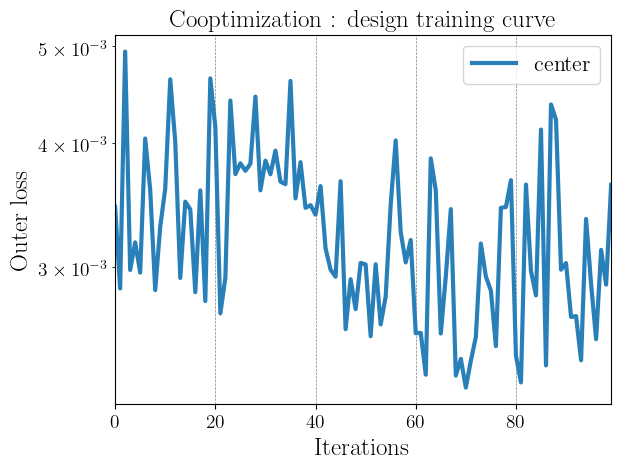

initial loss : 3.4477e-03
minimum loss : 2.2689e-03
iteration :  100


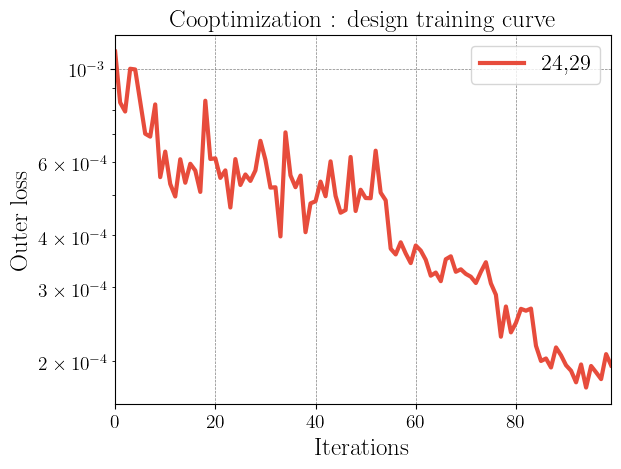

initial loss : 1.1025e-03
minimum loss : 1.7253e-04
complete data loading ---------------
iteration :  100


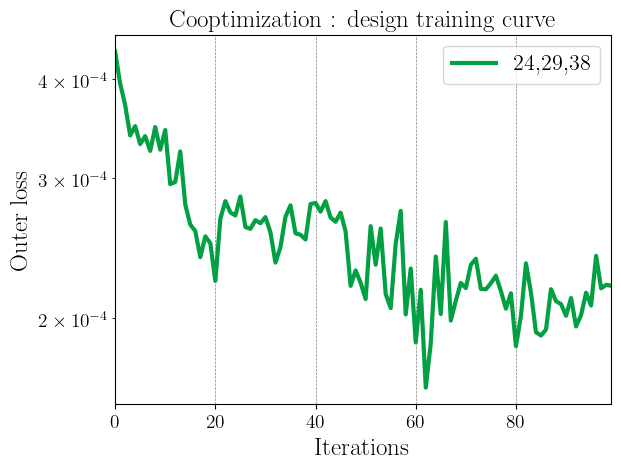

initial loss : 4.3312e-04
minimum loss : 1.6328e-04
complete data loading ---------------
iteration :  100


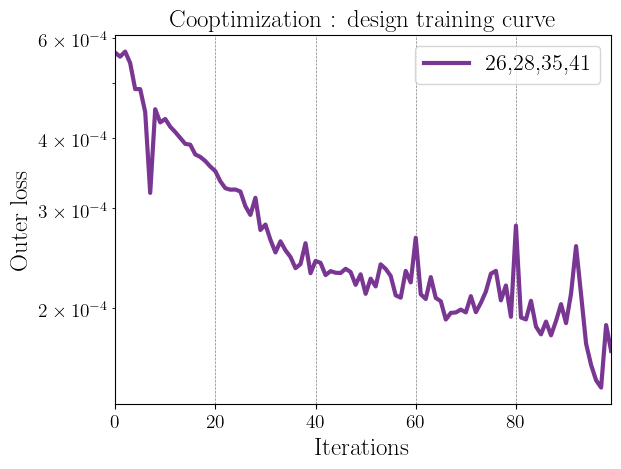

initial loss : 5.6530e-04
minimum loss : 1.4479e-04
iteration :  100


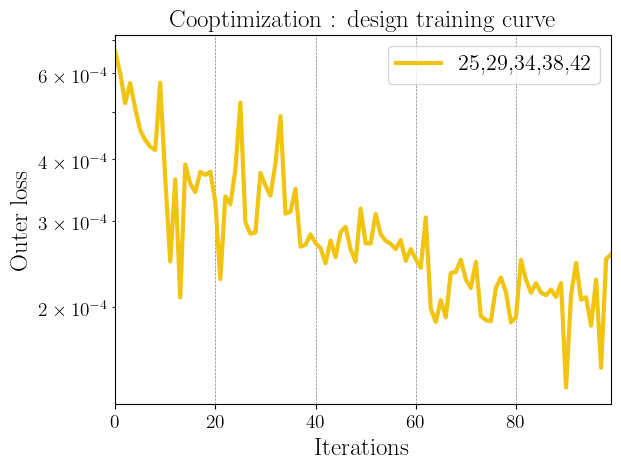

initial loss : 6.6439e-04
minimum loss : 1.3668e-04
[Array([0.00344771], dtype=float64), Array([0.00110253], dtype=float64), Array([0.00043312], dtype=float64), Array([0.0005653], dtype=float64), Array([0.00066439], dtype=float64)]
[Array([0.00226888], dtype=float64), Array([0.00017253], dtype=float64), Array([0.00016328], dtype=float64), Array([0.00014479], dtype=float64), Array([0.00013668], dtype=float64)]


In [21]:
# overall results
# one sensor case
init_loss_set = []
opt_loss_set = []

init_loss_temp = []
opt_loss_temp = []

with open(f"12152025_cooptimization_sim_1DCNN_data_300_n_source_4_retry.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]
print("iteration : ", len(loss_record))
k=0
plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[k], lw=3, label=f"center")
plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
plt.legend()
plt.show()
print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
init_loss_temp.append( jnp.array(loss_record)[0] )
opt_loss_temp.append( jnp.min(jnp.array(loss_record)) )
init_loss_set.append( jnp.array(init_loss_temp) )
opt_loss_set.append( jnp.array(opt_loss_temp) )


idx_set = [ (24,29)]
date_set = [ "12162025" ]
init_loss_temp = []
opt_loss_temp = []
for i in range(len(idx_set)):
    idx_1 = idx_set[i][0]
    idx_2 = idx_set[i][1]
    date = date_set[i]
    with open(date+f"_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_{idx_1}_{idx_2}_retry.pickle", "rb") as f:
        record_dict = pickle.load(f)

    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    loss_record = record_dict["loss_record"]
    print("iteration : ", len(loss_record))
    k = 1
    plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[k], lw=3, label=f"{idx_1},{idx_2}")
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend()
    plt.show()
    print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
    print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
    init_loss_temp.append( jnp.array(loss_record)[0] )
    opt_loss_temp.append( jnp.min(jnp.array(loss_record)) )

init_loss_set.append( jnp.array(init_loss_temp) )
opt_loss_set.append( jnp.array(opt_loss_temp) )

print("complete data loading ---------------")

idx_set = [ (24,29,38)]
date_set = [ "12152025" ]
init_loss_temp = []
opt_loss_temp = []
for i in range(len(idx_set)):

    idx_1 = idx_set[i][0]
    idx_2 = idx_set[i][1]
    idx_3 = idx_set[i][2]
    date = date_set[i]

    with open(date+f"_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_{idx_1}_{idx_2}_{idx_3}_retry.pickle", "rb") as f:
        record_dict = pickle.load(f)

    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    loss_record = record_dict["loss_record"]
    print("iteration : ", len(loss_record))
    k = 2
    plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[k], lw=3, label=f"{idx_1},{idx_2},{idx_3}")
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend()
    plt.show()
    print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
    print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
    init_loss_temp.append( jnp.array(loss_record)[0] )
    opt_loss_temp.append( jnp.min(jnp.array(loss_record)) )

init_loss_set.append( jnp.array(init_loss_temp) )
opt_loss_set.append( jnp.array(opt_loss_temp) )
print("complete data loading ---------------")

idx_set = [ (26,28,35,41) ]
date_set = [ "12162025" ]
init_loss_temp = []
opt_loss_temp = []
for i in range(len(idx_set)):

    idx_1 = idx_set[i][0]
    idx_2 = idx_set[i][1]
    idx_3 = idx_set[i][2]
    idx_4 = idx_set[i][3]
    date = date_set[i]

    with open(date+f"_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_{idx_1}_{idx_2}_{idx_3}_{idx_4}_retry.pickle", "rb") as f:
        record_dict = pickle.load(f)

    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    loss_record = record_dict["loss_record"]
    print("iteration : ", len(loss_record))
    k = 3
    plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[k], lw=3, label=f"{idx_1},{idx_2},{idx_3},{idx_4}")
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend()
    plt.show()
    print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
    print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

    init_loss_temp.append( jnp.array(loss_record)[0] )
    opt_loss_temp.append( jnp.min(jnp.array(loss_record)) )

init_loss_set.append( jnp.array(init_loss_temp) )
opt_loss_set.append( jnp.array(opt_loss_temp) )

idx_set = [ (25,29,34,38,42) ]
date_set = [ "12152025" ]
init_loss_temp = []
opt_loss_temp = []
for i in range(len(idx_set)):

    idx_1 = idx_set[i][0]
    idx_2 = idx_set[i][1]
    idx_3 = idx_set[i][2]
    idx_4 = idx_set[i][3]
    idx_5 = idx_set[i][4]
    date = date_set[i]

    with open(date+f"_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_{idx_1}_{idx_2}_{idx_3}_{idx_4}_{idx_5}_retry.pickle", "rb") as f:
        record_dict = pickle.load(f)

    param_record = record_dict["design_record"]
    in_param_record = record_dict["nn_record"]
    loss_record = record_dict["loss_record"]
    print("iteration : ", len(loss_record))
    k = 4
    plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), '-', color=color_list[k], lw=3, label=f"{idx_1},{idx_2},{idx_3},{idx_4},{idx_5}")
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend()
    plt.show()
    print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
    print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

    init_loss_temp.append( jnp.array(loss_record)[0] )
    opt_loss_temp.append( jnp.min(jnp.array(loss_record)) )

init_loss_set.append( jnp.array(init_loss_temp) )
opt_loss_set.append( jnp.array(opt_loss_temp) )
print( init_loss_set )
print( opt_loss_set )

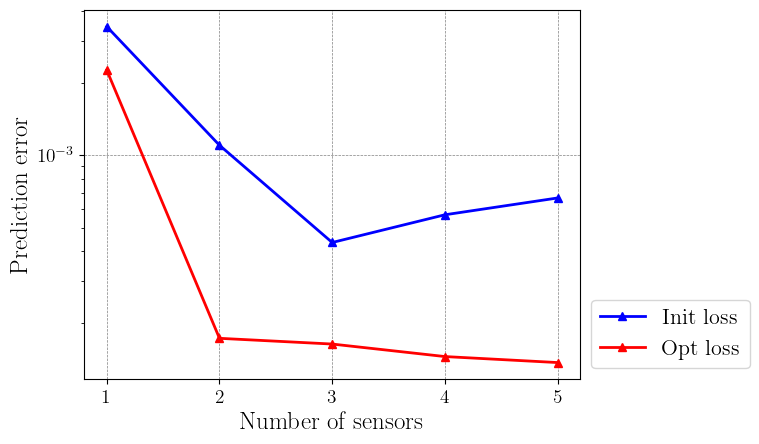

In [28]:
init_loss_array = jnp.array( init_loss_set )
opt_loss_array = jnp.array( opt_loss_set )

from matplotlib.ticker import MaxNLocator

N=5
fig, ax = plt.subplots()
marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
title_list = ["","Min", "Max", "Avg"]
i=0
plt.plot( jnp.arange(1,1+N), init_loss_array[:,i], linestyle=linestyle_list[i], marker=marker_list[i], color="b", label=title_list[i]+" Init loss" )
plt.plot( jnp.arange(1,1+N), opt_loss_array[:,i], linestyle=linestyle_list[i], marker=marker_list[i], color="r", label=title_list[i]+" Opt loss" )
# plt.axhline(y=opt_loss_array[0,0], color='gray', linestyle='-.', label='Reference Line')
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.yscale("log")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Number of sensors")
plt.ylabel("Prediction error")
plt.show()

In [52]:
# sensor 1

with open(f"05082025_implicit_learning_simple_1DCNN_iter_100_1000_lr_0.1_0.01_data_300_n_source_4.pickle", "rb") as f:
    record_dict = pickle.load(f)

param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

init_loss = jnp.array(loss_record)[0]
opt_loss = jnp.min(jnp.array(loss_record))
init_loss_temp = jnp.array([init_loss, init_loss, init_loss])
opt_loss_temp = jnp.array([opt_loss, opt_loss, opt_loss])

print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")

init_loss_set.insert( 0, jnp.array(init_loss_temp) )
opt_loss_set.insert( 0, jnp.array(opt_loss_temp) )

initial loss : 1.2397e-02
minimum loss : 4.1805e-03


In [53]:
init_loss_array = jnp.stack( init_loss_set )
opt_loss_array = jnp.stack( opt_loss_set )

print( init_loss_set )
print( init_loss_array )

[Array([0.01239749, 0.01239749, 0.01239749], dtype=float64), Array([0.00414476, 0.00567043, 0.00467536], dtype=float64), Array([0.00437606, 0.00372651, 0.00375185], dtype=float64), Array([0.00218953, 0.00336993, 0.00231864], dtype=float64)]
[[0.01239749 0.01239749 0.01239749]
 [0.00414476 0.00567043 0.00467536]
 [0.00437606 0.00372651 0.00375185]
 [0.00218953 0.00336993 0.00231864]]


In [ ]:

def load_and_plot(path, color, label):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    plt.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    print("-------------------------------------------")
    return loss[0], loss.min()

init_loss_set, opt_loss_set = [], []
# One sensor: just the center
path = "12142025_cooptimization_sim_1DCNN_data_300_n_source_8.pickle"
init, opt = load_and_plot(path, color_list[0], "center")
init_loss_set.append(jnp.array([init]))
opt_loss_set.append(jnp.array([opt]))

# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs = [
    ([(52,62)],            ["12142025"], 1),
    ([(52,57,62)],         ["12142025"], 2),
    ([(49,55,60,65)],      ["12142025"], 3),
    ([(49,53,57,61,65)],   ["12242025"], 4),
    ([(28,34,40,97,103,109)], ["12252025"], 5),
]

plt.figure(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}"
        fname += ".pickle"
        init, opt = load_and_plot(fname, color_list[k], idx_str)
        init_temp.append(init)
        opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))

print(init_loss_set)
print(opt_loss_set)


plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.show()

# 8 input source

In [9]:
n1_blocks = 23
n2_blocks = 6
n_source = 8
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
bond_length = 0.075*15.  # Same as bond length
initial_angle = -25.0*jnp.pi/180
horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

geometry = QuadGeometry_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_source=n_source
)

In [ ]:
from blockymetamaterials.plotting_input import plot_geometry

def load_and_plot(path, color, label, ax, show=False, colors="#2980b9"):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    return loss[0], loss.min()

color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]
init_loss_set, opt_loss_set = [], []
configs_set = [
    [([(57,)],              ["01062026"], 0),
    ([(62,)],              ["01192026"], 0),
    ([(53,)],              ["01172026"], 0),
    ([(75,)],              ["01232026"], 0),
    ([(80,)],              ["01232026"], 0)], # 1 sensor
    [([(52,62)],            ["01062026"], 1),
    ([(75,62)],            ["01172026"], 1),
    ([(75,85)],            ["01172026"], 1),
    ([(77,83)],            ["01232026"], 1),
    ([(60,77)],            ["01242026"], 1)], # 2 sensors
    [([(52,57,62)],         ["01062026"], 2),
    ([(52,80,108)],         ["01172026"], 2),
    ([(57,75,85)],         ["01172026"], 2),
    ([(49,65,80)],         ["01242026"], 2),
    ([(75,80,85)],         ["01242026"], 2)], # 3 sensors
    [([(49,55,60,65)],      ["01062026"], 3),
    # ([(72,78,83,88)],      ["01182026"], 1),
    ([(55,60,75,85)],      ["01182026"], 3),
    ([(41,52,75,85)],      ["01242026"], 3),
    ([(41,52,77,83)],      ["01242026"], 3),
    ([(49,60,100,111)],     ["03042026"], 3)],
    # ([(52,62,98,108)],     ["03042026"], 6),
    # ([(74,86,96,106)],     ["03052026"], 7)], # 4 sensors
    [([(49,53,57,61,65)],   ["01062026"], 4),
    ([(72,76,80,84,88)],   ["01162026"], 4),
    ([(49,57,65,76,84)],   ["01172026"], 4),
    ([(53,61,74,86,103)],   ["01252026"], 4),
    ([(53,57,61,74,86)],   ["01252026"], 4)], # 5 sensors
    [([(28,34,40,97,103,109)], ["01072026"], 5),
    ([(49,56,63,97,104,111)], ["01172026"], 5),
    ([(49,54,59,63,98,106)], ["01172026"], 5),
    ([(51,55,59,63,79,84)], ["01242026"], 5),
    ([(52,57,62,74,86,103)], ["01242026"], 5) ] # 6 sensors
]
change_design = []

for m in range(len(configs_set)):
    configs = configs_set[m]
    init_temp, opt_temp = [], []
    for idx_set, date_set, k in configs:
        init_temp, opt_temp = [], []
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            if len(idx_tuple) == 1:
                idx_str = str(idx_tuple[0])
            else:
                idx_str = ",".join(str(x) for x in idx_tuple)

            if len(idx_tuple) == 1:
                file_idx = str(idx_tuple[0])
            else:
                file_idx = "_".join(str(x) for x in idx_tuple)

            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"

            hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
            with open(fname, "rb") as f:
                record = pickle.load(f)

            param_record = record["design_record"]
            loss_record = record["loss_record"]

            init_hori_shifts = param_record[0][:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
            init_vert_shifts = param_record[0][hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

            opt_idx = jnp.argmin(jnp.array(loss_record))
            print("opt_idx:", opt_idx)
            meta_params = param_record[opt_idx]
            horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
            vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
            design_values = (horizontal_shifts, vertical_shifts)

            diff_design = jnp.mean( jnp.abs( init_hori_shifts - horizontal_shifts ) ) + jnp.mean( jnp.abs( init_vert_shifts - vertical_shifts ) )
            change_design.append( diff_design )

            colors = [color_list[k] for j in range(geometry.n_blocks)]
            
            for j in idx_tuple:
                colors[j] = "k"

            xlim, ylim = geometry.get_xy_limits(
                *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
        
            fig, ax = plot_geometry(
                block_centroids=geometry.block_centroids(*design_values),
                centroid_node_vectors=geometry.centroid_node_vectors(
                    *design_values),
                bond_connectivity=geometry.bond_connectivity(),
                xlim=xlim,
                ylim=ylim,
                figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
                color=colors
            )
            ax.axis("off")
            # plt.title(f"Minimum loss design")
            plt.savefig(f"Figure/8_input_source/8_input_source_minimum_loss_design_{file_idx}.eps")
            plt.show()
        print("-------------------------------------------")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


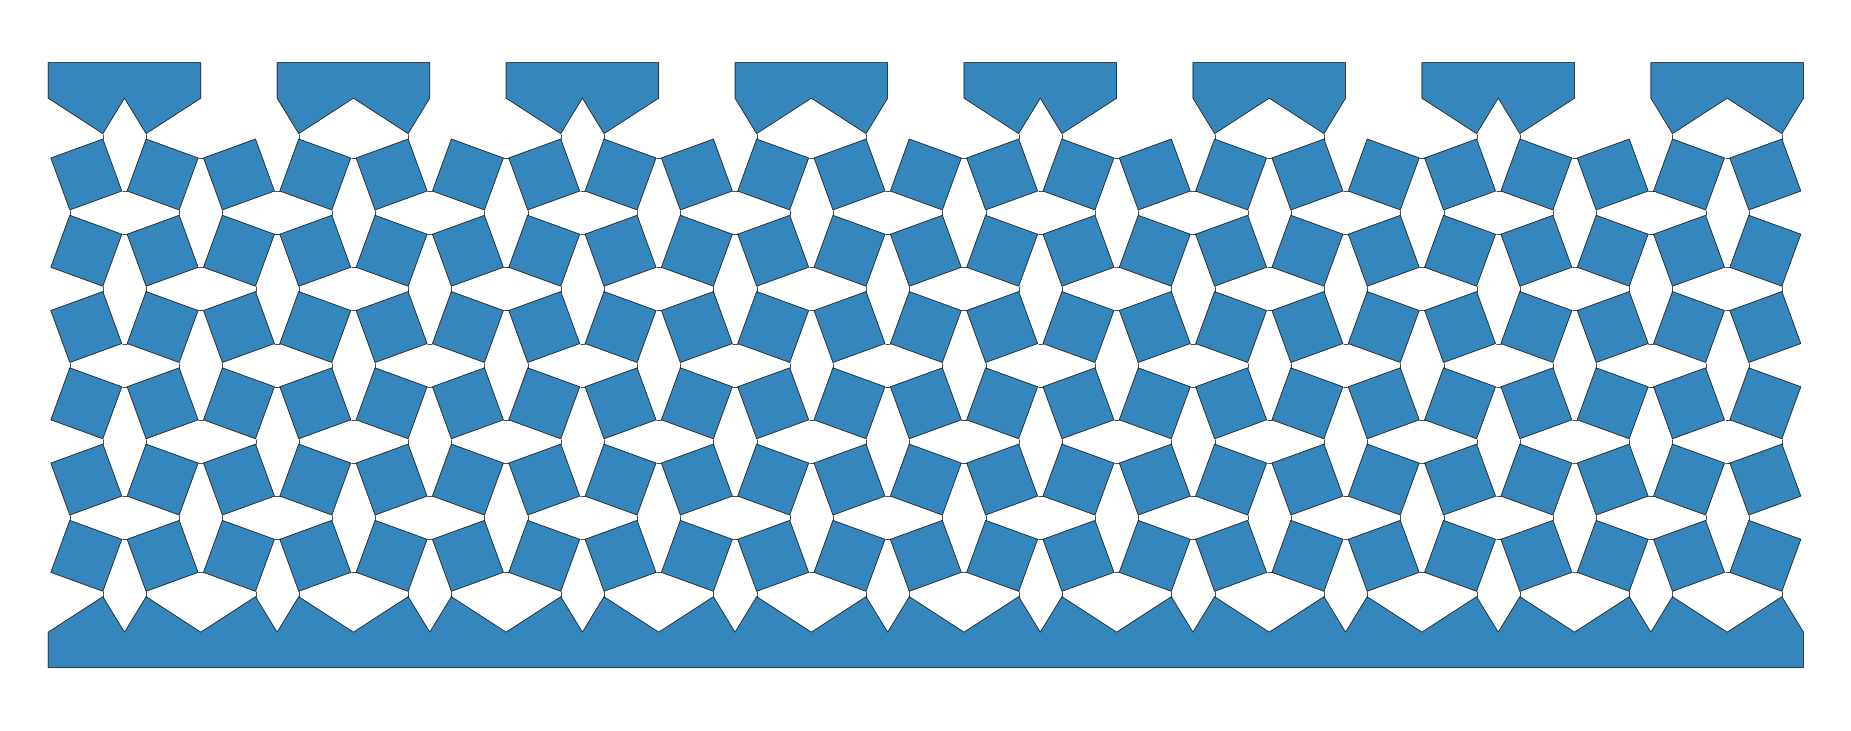

In [85]:
from blockymetamaterials.plotting_input import generate_animation, generate_frames, plot_geometry, generate_patch_collection

design_values = (horizontal_shifts, vertical_shifts)
colors = [color_list[0] for j in range(geometry.n_blocks)]

# for j in (49,54,59,63,98,106):
#     colors[j] = "k"

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
    color=colors
)
ax.axis("off")
plt.savefig('Figure/8_input_source_initial_design.eps')
plt.show()

center
initial loss : 2.2723e-03
minimum loss : 1.4137e-03
-------------------------------------------
52,62
initial loss : 2.1270e-03
minimum loss : 5.5262e-04
-------------------------------------------
52,57,62
initial loss : 1.1129e-03
minimum loss : 5.4439e-04
-------------------------------------------
49,55,60,65
initial loss : 1.1255e-03
minimum loss : 4.0739e-04
-------------------------------------------
49,53,57,61,65
initial loss : 7.7782e-04
minimum loss : 3.0259e-04
-------------------------------------------
28,34,40,97,103,109
initial loss : 5.5426e-04
minimum loss : 2.2360e-04
-------------------------------------------
[Array([0.00227226], dtype=float64), Array([0.00212702], dtype=float64), Array([0.00111287], dtype=float64), Array([0.0011255], dtype=float64), Array([0.00077782], dtype=float64), Array([0.00055426], dtype=float64)]
[Array([0.00141371], dtype=float64), Array([0.00055262], dtype=float64), Array([0.00054439], dtype=float64), Array([0.00040739], dtype=floa

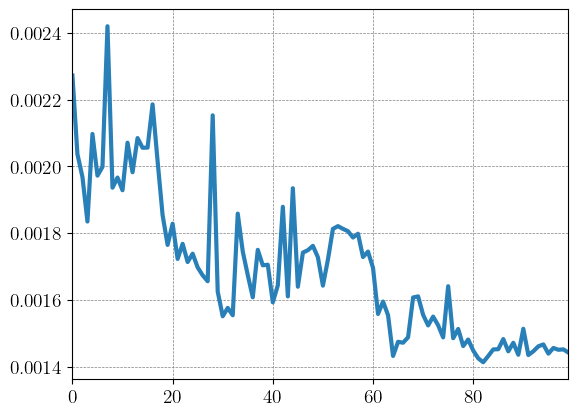

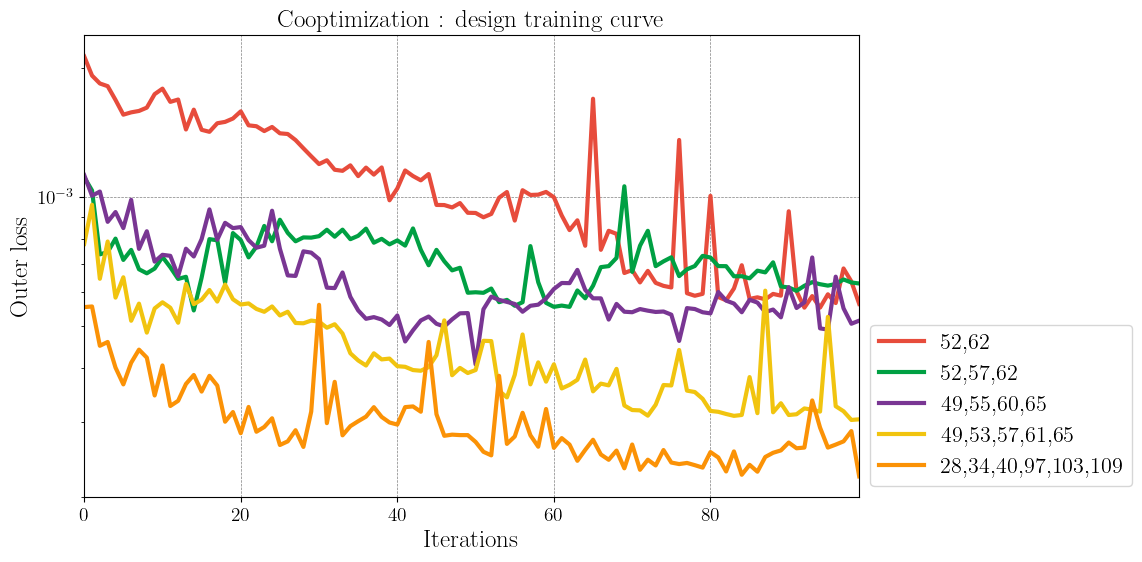

In [ ]:
# Concise summary for different sensor/sensor-set training curves

def load_and_plot(path, color, label):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    plt.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    print("-------------------------------------------")
    return loss[0], loss.min()

init_loss_set, opt_loss_set = [], []
# One sensor: just the center
path = "12142025_cooptimization_sim_1DCNN_data_300_n_source_8.pickle"
init, opt = load_and_plot(path, color_list[0], "center")
init_loss_set.append(jnp.array([init]))
opt_loss_set.append(jnp.array([opt]))

# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs = [
    ([(52,62)],            ["12142025"], 1),
    ([(52,57,62)],         ["12142025"], 2),
    ([(49,55,60,65)],      ["12142025"], 3),
    ([(49,53,57,61,65)],   ["12242025"], 4),
    ([(28,34,40,97,103,109)], ["12252025"], 5),
]

plt.figure(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}"
        fname += ".pickle"
        init, opt = load_and_plot(fname, color_list[k], idx_str)
        init_temp.append(init)
        opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))

print(init_loss_set)
print(opt_loss_set)


plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.show()

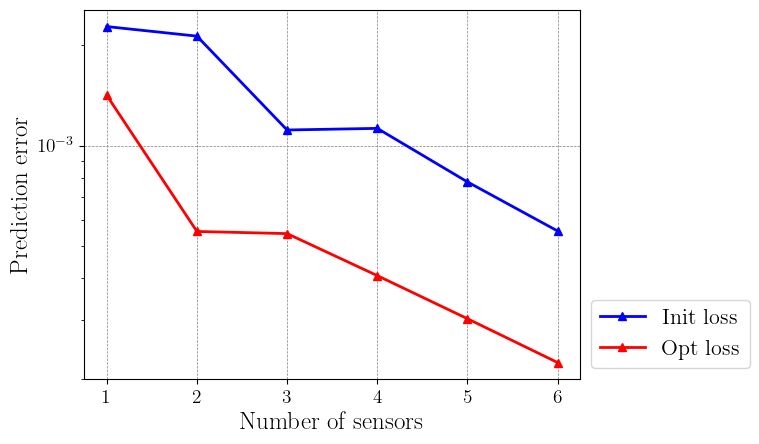

In [31]:
init_loss_array = jnp.array( init_loss_set )
opt_loss_array = jnp.array( opt_loss_set )

from matplotlib.ticker import MaxNLocator

N=6
fig, ax = plt.subplots()
marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
title_list = ["","Min", "Max", "Avg"]
i=0
plt.plot( jnp.arange(1,1+N), init_loss_array[:,i], linestyle=linestyle_list[i], marker=marker_list[i], color="b", label=title_list[i]+" Init loss" )
plt.plot( jnp.arange(1,1+N), opt_loss_array[:,i], linestyle=linestyle_list[i], marker=marker_list[i], color="r", label=title_list[i]+" Opt loss" )
# plt.axhline(y=opt_loss_array[0,0], color='gray', linestyle='-.', label='Reference Line')
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.yscale("log")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Number of sensors")
plt.ylabel("Prediction error")
plt.show()

In [ ]:
configs = [
    ([(52,62)],            ["12142025"], 1),
    ([(52,57,62)],         ["12142025"], 2),
    ([(49,55,60,65)],      ["12142025"], 3),
    ([(49,53,57,61,65)],   ["12242025"], 4),
    ([(28,34,40,97,103,109)], ["12252025"], 5),
]

plt.figure(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}"
        fname += ".pickle"
        colors = ["#6196ca" for j in range(geometry.n_blocks)]
        for j in idx_tuple:
            colors[j] = "k"

        xlim, ylim = geometry.get_xy_limits(
            *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
        fig, ax = plot_geometry(
            block_centroids=geometry.block_centroids(*design_values),
            centroid_node_vectors=geometry.centroid_node_vectors(
                *design_values),
            bond_connectivity=geometry.bond_connectivity(),
            xlim=xlim,
            ylim=ylim,
            figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
            color=colors
        )
        ax.axis("off")
        plt.savefig(f'Figure/8_input_source/8_input_source_idx_{file_idx}.eps', dpi=300, bbox_inches='tight', pad_inches=0)
        plt.show()

## Retry

In [ ]:

def load_and_plot(path, color, label, ax):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])

    ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")

    return loss[0], loss.min()

init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs = [
    ([(57,)],              ["01062026"], 0),
    ([(52,62)],            ["01062026"], 1),
    ([(52,57,62)],         ["01062026"], 2),
    ([(49,55,60,65)],      ["01062026"], 3),
    ([(49,53,57,61,65)],   ["01062026"], 4),
    ([(28,34,40,97,103,109)], ["01072026"], 5),
]

fig, ax = plt.subplots(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

        colors = [color_list[k] for j in range(geometry.n_blocks)]
        print(len(colors))
        
        for j in idx_tuple:
            colors[j] = "k"

        init, opt = load_and_plot(fname, color_list[k], idx_str, ax)
        init_temp.append(init)
        opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
print(init_loss_set)
print(opt_loss_set)

ax.set_title('Cooptimization : design training curve')
ax.set_yscale('log')
ax.set_ylabel("Outer loss")
ax.set_xlabel("Iterations")
ax.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.show()


change_design = []

for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

        hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
        with open(fname, "rb") as f:
            record = pickle.load(f)

        param_record = record["design_record"]
        loss_record = record["loss_record"]

        init_hori_shifts = param_record[0][:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        init_vert_shifts = param_record[0][hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

        opt_idx = jnp.argmin(jnp.array(loss_record))
        meta_params = param_record[opt_idx]
        horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
        design_values = (horizontal_shifts, vertical_shifts)

        diff_design = jnp.mean( jnp.abs( init_hori_shifts - horizontal_shifts ) ) + jnp.mean( jnp.abs( init_vert_shifts - vertical_shifts ) )
        change_design.append( diff_design )

        colors = [color_list[k] for j in range(geometry.n_blocks)]
        
        for j in idx_tuple:
            colors[j] = "k"

        xlim, ylim = geometry.get_xy_limits(
            *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
    
        fig, ax = plot_geometry(
            block_centroids=geometry.block_centroids(*design_values),
            centroid_node_vectors=geometry.centroid_node_vectors(
                *design_values),
            bond_connectivity=geometry.bond_connectivity(),
            xlim=xlim,
            ylim=ylim,
            figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
            color=colors
        )
        ax.axis("off")
        plt.title(f"Minimum loss design")
        plt.show()
    print("-------------------------------------------")

In [ ]:

def load_and_plot(path, color, label, ax, show=False, colors="#2980b9"):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    return loss[0], loss.min()

color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]
init_loss_set, opt_loss_set = [], []
configs =[
    ([(49,55,60,65)],      ["01062026"], 3)
]
change_design = []

for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

        hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
        with open(fname, "rb") as f:
            record = pickle.load(f)

        param_record = record["design_record"]
        loss_record = record["loss_record"]

        init_hori_shifts = param_record[0][:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        init_vert_shifts = param_record[0][hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

        opt_idx = jnp.argmin(jnp.array(loss_record))
        meta_params = param_record[opt_idx]
        horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
        design_values = (horizontal_shifts, vertical_shifts)

        diff_design = jnp.mean( jnp.abs( init_hori_shifts - horizontal_shifts ) ) + jnp.mean( jnp.abs( init_vert_shifts - vertical_shifts ) )
        change_design.append( diff_design )

        colors = [color_list[k] for j in range(geometry.n_blocks)]
        
        for j in idx_tuple:
            colors[j] = "k"

        xlim, ylim = geometry.get_xy_limits(
            *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
    
        fig, ax = plot_geometry(
            block_centroids=geometry.block_centroids(*design_values),
            centroid_node_vectors=geometry.centroid_node_vectors(
                *design_values),
            bond_connectivity=geometry.bond_connectivity(),
            xlim=xlim,
            ylim=ylim,
            figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
            color=colors
        )
        ax.axis("off")
        # plt.title(f"Minimum loss design")
        plt.savefig(f"Figure/8_input_source_minimum_loss_design_{file_idx}.eps")
        plt.show()
    print("-------------------------------------------")

NameError: name 'n1_blocks' is not defined

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


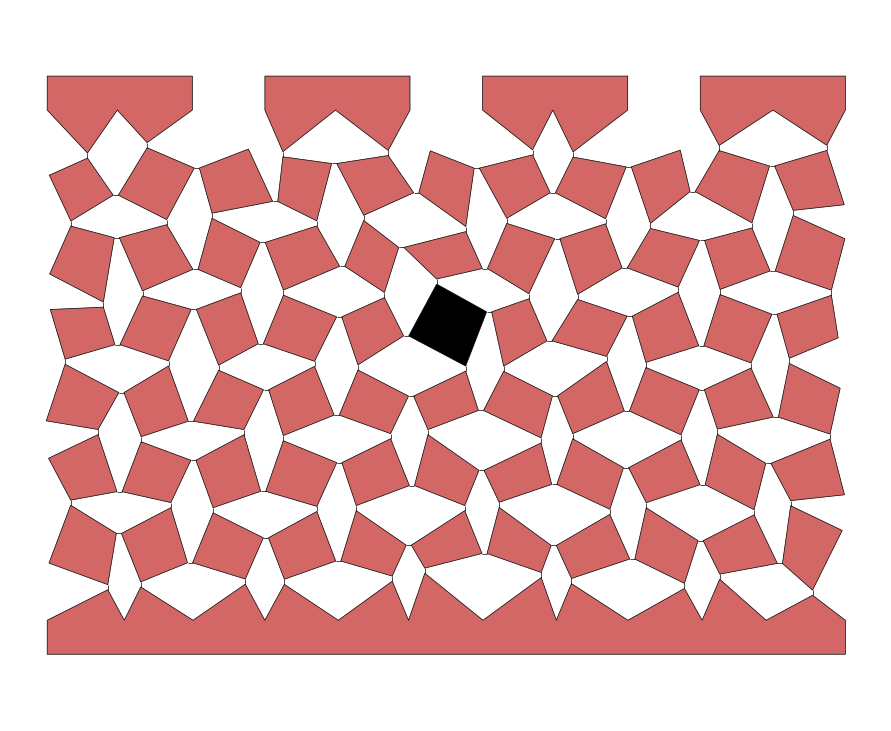

-------------------------------------------


In [12]:

def load_and_plot(path, color, label, ax, show=False, colors="#2980b9"):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    
    return loss[0], loss.min()
color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]
init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
# configs = [
#     ([(38,)],              ["01062026"], 0),
#     ([(25,29)],            ["01062026"], 1),
#     ([(25,29,38)],         ["01062026"], 2),
#     ([(26,28,35,41)],      ["01062026"], 3),
#     ([(25,29,34,38,42)],   ["01062026"], 4),
#     ([(13,16,19,35,38,41)], ["01062026"], 5),
# ]
# configs = [
#     ([(38,)],              ["01062026"], 0),
#     ([(25,29)],            ["01062026"], 1),
#     ([(25,29,38)],         ["01062026"], 2),
#     ([(26,28,35,41)],      ["01062026"], 3),
#     ([(25,29,34,38,42)],   ["01062026"], 4),
#     ([(13,16,19,35,38,41)], ["01062026"], 5),
#     ([(27,)],               ["01142026"], 0),
#     ([(49,)],               ["01142026"], 0),
#     ([(24,)],               ["01232026"], 0),
#     ([(30,)],               ["01232026"], 0), # 1 sensor
#     ([(24,41)],             ["01162026"], 1),
#     ([(35,30)],             ["01162026"], 1),
#     ([(13,30)],             ["01232026"], 1),
#     ([(19,35)],             ["01232026"], 1), # 2 sensors
#     ([(27,35,41)],          ["01162026"], 2),
#     ([(24,30,38)],          ["01162026"], 2),
#     ([(19,27,35)],          ["01232026"], 2),
#     ([(13,27,41)],          ["01232026"], 2), # 3 sensors
#     ([(24,30,37,39)],       ["01162026"], 3),
#     ([(26,28,41,46)],       ["01162026"], 3),
#     ([(15,17,37,39)],       ["01262026"], 3),
#     ([(25,29,47,51)],       ["01252026"], 3), # 4 sensors
#     ([(23,27,31,36,40)],    ["01162026"], 4),
#     ([(23,25,27,29,31)],    ["01162026"], 4),
#     ([(24,30,35,38,41)],    ["01252026"], 4),
#     ([(13,27,30,39,46)],    ["01262026"], 4), # 5 sensors
#     ([(24,27,30,36,39,42)], ["01162026"], 5),
#     ([(24,27,30,47,50,53)], ["01162026"], 5),
#     ([(14,18,25,29,36,40)], ["01252026"], 5),
#     ([(25,29,36,40,47,51)], ["01252026"], 5) # 6 sensors
# ]
configs =[
    ([(38,)],              ["01062026"], 0)
]
# fig, ax = plt.subplots(figsize=(10, 6))
# for idx_set, date_set, k in configs:
#     init_temp, opt_temp = [], []
#     for i, idx_tuple in enumerate(idx_set):
#         date = date_set[i]
#         if len(idx_tuple) == 1:
#             idx_str = str(idx_tuple[0])
#         else:
#             idx_str = ",".join(str(x) for x in idx_tuple)

#         if len(idx_tuple) == 1:
#             file_idx = str(idx_tuple[0])
#         else:
#             file_idx = "_".join(str(x) for x in idx_tuple)

#         fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
#         if len(idx_tuple) > 0:
#             fname += f"_measure_idx_{file_idx}_without_contact"
#         fname += ".pickle"

#         colors = [color_list[k] for j in range(geometry.n_blocks)]
#         print(len(colors))
        
#         for j in idx_tuple:
#             colors[j] = "k"

#         init, opt = load_and_plot(fname, color_list[k], idx_str, ax, show=True, colors=colors)
#         init_temp.append(init)
#         opt_temp.append(opt)
#     init_loss_set.append(jnp.array(init_temp))
#     opt_loss_set.append(jnp.array(opt_temp))
# print(init_loss_set)
# print(opt_loss_set)


# ax.set_title('Cooptimization : design training curve')
# ax.set_yscale('log')
# ax.set_ylabel("Outer loss")
# ax.set_xlabel("Iterations")
# ax.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
# plt.show()

change_design = []

for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

        hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
        with open(fname, "rb") as f:
            record = pickle.load(f)

        param_record = record["design_record"]
        loss_record = record["loss_record"]

        init_hori_shifts = param_record[0][:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        init_vert_shifts = param_record[0][hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

        opt_idx = jnp.argmin(jnp.array(loss_record))
        meta_params = param_record[opt_idx]
        horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
        vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
        design_values = (horizontal_shifts, vertical_shifts)

        diff_design = jnp.mean( jnp.abs( init_hori_shifts - horizontal_shifts ) ) + jnp.mean( jnp.abs( init_vert_shifts - vertical_shifts ) )
        change_design.append( diff_design )

        colors = [color_list[k] for j in range(geometry.n_blocks)]
        
        for j in idx_tuple:
            colors[j] = "k"

        xlim, ylim = geometry.get_xy_limits(
            *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
    
        fig, ax = plot_geometry(
            block_centroids=geometry.block_centroids(*design_values),
            centroid_node_vectors=geometry.centroid_node_vectors(
                *design_values),
            bond_connectivity=geometry.bond_connectivity(),
            xlim=xlim,
            ylim=ylim,
            figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
            color=colors
        )
        ax.axis("off")
        # plt.title(f"Minimum loss design")
        plt.savefig(f"Figure/4_input_source/Design/4_input_source_minimum_loss_design_{file_idx}.eps")
        plt.show()
    print("-------------------------------------------")

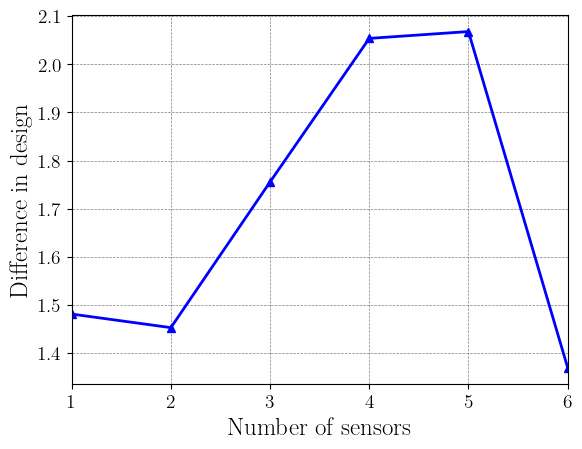

In [27]:
N=6

marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
title_list = ["","Min", "Max", "Avg"]
i=0
plt.plot( jnp.arange(1,1+N), jnp.array(change_design), linestyle=linestyle_list[i], marker=marker_list[i], color="b")
plt.xlabel("Number of sensors")
plt.ylabel("Difference in design")
plt.show()

38
initial loss : 7.7943e-04
minimum loss : 4.5767e-04
-------------------------------------------
25,29
initial loss : 3.5990e-04
minimum loss : 1.1999e-04
-------------------------------------------
25,29,38
initial loss : 2.8193e-04
minimum loss : 9.6069e-05
-------------------------------------------
26,28,35,41
initial loss : 3.3671e-04
minimum loss : 6.6182e-05
-------------------------------------------
25,29,34,38,42
initial loss : 2.3155e-04
minimum loss : 6.4821e-05
-------------------------------------------
13,16,19,35,38,41
initial loss : 2.9366e-04
minimum loss : 9.3275e-05
-------------------------------------------
[Array([0.00077943], dtype=float64), Array([0.0003599], dtype=float64), Array([0.00028193], dtype=float64), Array([0.00033671], dtype=float64), Array([0.00023155], dtype=float64), Array([0.00029366], dtype=float64)]
[Array([0.00045767], dtype=float64), Array([0.00011999], dtype=float64), Array([9.60685954e-05], dtype=float64), Array([6.61820323e-05], dtype=fl

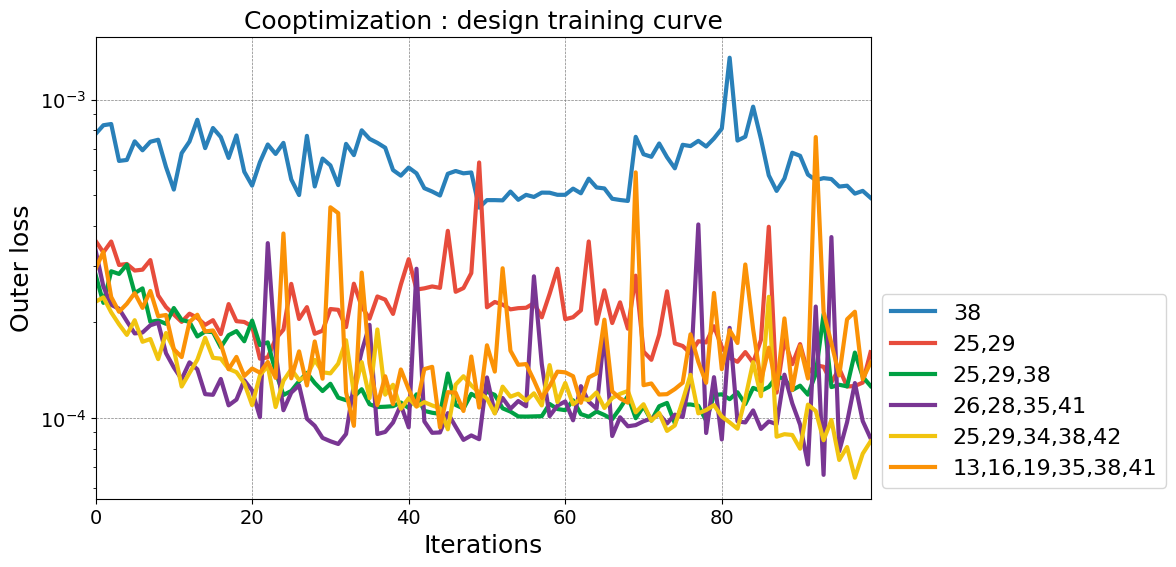

In [23]:

def load_and_plot(path, color, label):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    plt.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    print("-------------------------------------------")
    return loss[0], loss.min()

init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs = [
    ([(38,)],              ["01062026"], 0),
    ([(25,29)],            ["01062026"], 1),
    ([(25,29,38)],         ["01062026"], 2),
    ([(26,28,35,41)],      ["01062026"], 3),
    ([(25,29,34,38,42)],   ["01062026"], 4),
    ([(13,16,19,35,38,41)], ["01062026"], 5),
]

plt.figure(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"
        init, opt = load_and_plot(fname, color_list[k], idx_str)
        init_temp.append(init)
        opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
print(init_loss_set)
print(opt_loss_set)


plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.show()

In [ ]:
def load_and_plot(path, color, label):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    plt.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
    print(label)
    print(f"initial loss : {loss[0]:.4e}")
    print(f"minimum loss : {loss.min():.4e}")
    print("-------------------------------------------")

    param_record = record["design_record"]
    loss_record = record["loss_record"]

    init_hori_shifts = param_record[0][:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    init_vert_shifts = param_record[0][hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))

    opt_idx = jnp.argmin(jnp.array(loss_record))
    meta_params = param_record[opt_idx]
    horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
    vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
    design_values = (horizontal_shifts, vertical_shifts)
    diff_design = jnp.mean( jnp.abs( init_hori_shifts - horizontal_shifts ) ) + jnp.mean( jnp.abs( init_vert_shifts - vertical_shifts ) )
    print( "difference in design : ", diff_design )
    colors = [color_list[k] for j in range(geometry.n_blocks)]
    
    for j in idx_tuple:
        colors[j] = "k"

    xlim, ylim = geometry.get_xy_limits(
        *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])

    fig, ax = plot_geometry(
        block_centroids=geometry.block_centroids(*design_values),
        centroid_node_vectors=geometry.centroid_node_vectors(
            *design_values),
        bond_connectivity=geometry.bond_connectivity(),
        xlim=xlim,
        ylim=ylim,
        figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
        color=colors
    )
    ax.axis("off")
    # plt.title(f"Minimum loss design")
    plt.savefig(f"Figure/4_input_source_minimum_loss_design_{label}.eps")
    plt.show()
    return loss[0], loss.min()

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
configs =[
    ([(38,)],              ["01062026"], 1),
    ([(49,)],               ["01142026"], 1)
]

plt.figure(figsize=(10, 6))
for idx_set, date_set, k in configs:
    init_temp, opt_temp = [], []
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        if len(idx_tuple) == 1:
            idx_str = str(idx_tuple[0])
        else:
            idx_str = ",".join(str(x) for x in idx_tuple)

        if len(idx_tuple) == 1:
            file_idx = str(idx_tuple[0])
        else:
            file_idx = "_".join(str(x) for x in idx_tuple)

        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"
        init, opt = load_and_plot(fname, color_list[k], idx_str)
        init_temp.append(init)
        opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
print(init_loss_set)
print(opt_loss_set)


plt.title('Cooptimization : design training curve')
plt.yscale('log')
plt.ylabel("Outer loss")
plt.xlabel("Iterations")
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.show()

/tmp/ipykernel_2789350/2019311657.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Spectral")
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


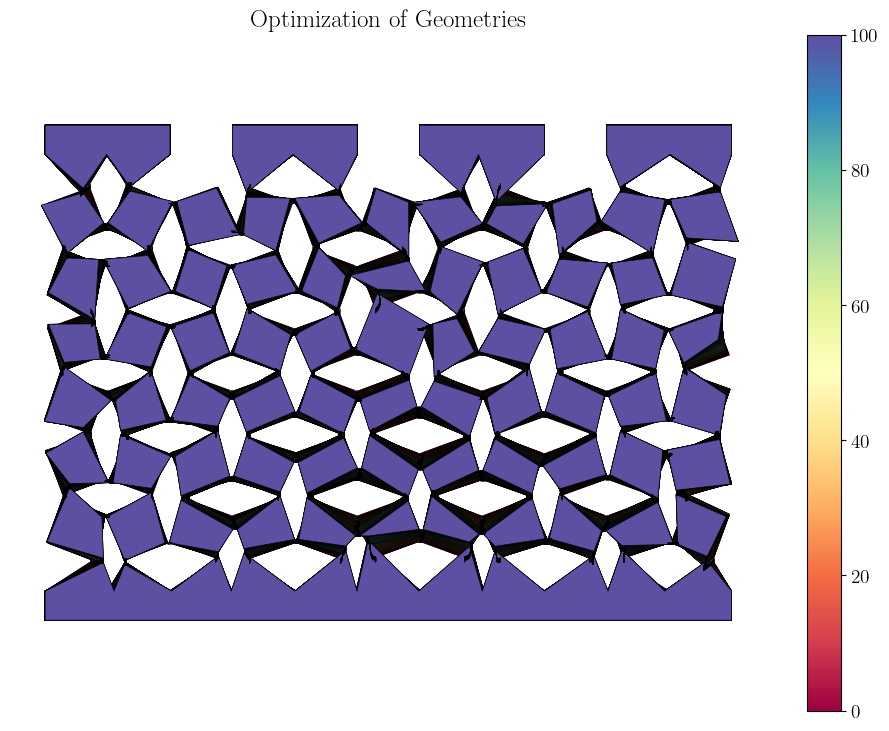

In [24]:
# check performance of 4 input source

# n1_blocks = 11
# n2_blocks = 6
# n_source = 4
# spacing = 15. + 0.075*15.  # 1.0  # 15 mm
# hinge_length = 0.075*15.  # Same as bond length
# initial_angle = -25.0*jnp.pi/180
# horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
#     angle=initial_angle,
# )  # Initial design

# # Mechanical params
# k_stretch = 4.00  # stretching stiffness 120. N/mm
# k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
# k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm

# min_angle=-15*jnp.pi/180
# cutoff_angle=-10*jnp.pi/180

# simulation_time = 1.0
# n_timepoints = 200
# bond_length = hinge_length
# linearized_strains = True # change from False to True for linearized strains
# use_contact = True
# k_contact = k_rot

# geometry = QuadGeometry_InputSource(
#     n1_blocks=n1_blocks,
#     n2_blocks=n2_blocks,
#     spacing=spacing,
#     bond_length=bond_length,
#     n_source=n_source
# )

# block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
# _bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
# _reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant


# hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
# with open("01062026_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_38_without_contact.pickle", "rb") as f:
#     record_dict = pickle.load(f)
# param_record = record_dict["design_record"]
# in_param_record = record_dict["nn_record"]
# loss_record = record_dict["loss_record"]

# plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)

# opt_idx = jnp.argmin(jnp.array(loss_record))
# print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
# print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
# print("minimum loss idx : ", opt_idx)

# meta_params = param_record[opt_idx]
# horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
# vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
# design_values = (horizontal_shifts, vertical_shifts)
# iter_num = len(loss_record)
# geometry_data = []

# for i in range(iter_num):
#     meta_params = param_record[i]
#     horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
#     vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
#     design_values = (horizontal_shifts, vertical_shifts)

#     geometry_data.append({
#         "block_centroids": geometry.block_centroids(*design_values),
#         "centroid_node_vectors": geometry.centroid_node_vectors(*design_values),
#         "bond_connectivity": geometry.bond_connectivity(),
#         "deformed": False
#     })

# from matplotlib import cm, colors
# from blockymetamaterials.plotting_input import plot_multiple_geometries

# Example Usage
cmap = cm.get_cmap("Spectral")
color_list_multi = cmap( jnp.linspace(0.0, 1.0, iter_num) ) # extract 20 colors from cmap
norm = colors.Normalize(0, iter_num)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
# Plot all geometries in one figure
fig, ax = plot_multiple_geometries(geometry_data, figsize=(4 * n1_blocks/5, 6 * n2_blocks/5), colors=color_list_multi, xlim=xlim, ylim=ylim)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.set_title("Optimization of Geometries")
ax.axis("off")
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


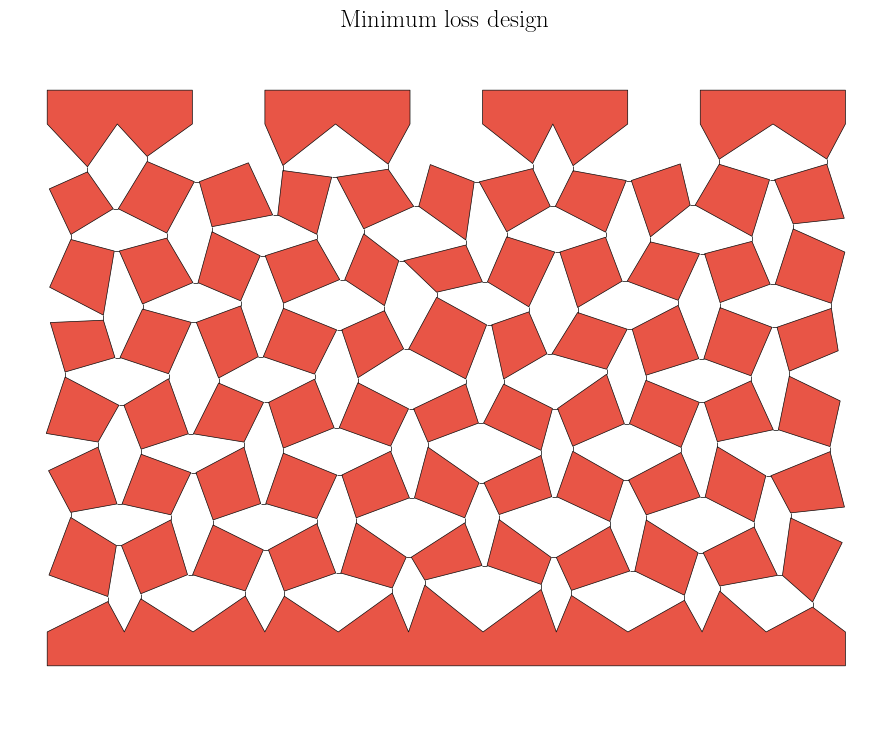

In [41]:
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
opt_idx = jnp.argmin(jnp.array(loss_record))
print(f"initial loss : {jnp.array(loss_record)[0]:.4e}")
print(f"minimum loss : {jnp.min(jnp.array(loss_record)):.4e}")
print("minimum loss idx : ", opt_idx)
meta_params = param_record[opt_idx]
horizontal_shifts = meta_params[:hori_shifts_length].reshape((n1_blocks+1, n2_blocks, 2))
vertical_shifts = meta_params[hori_shifts_length:].reshape((n1_blocks, n2_blocks+1, 2))
design_values = (horizontal_shifts, vertical_shifts)

xlim, ylim = geometry.get_xy_limits(
    *design_values) + 0.5*geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(
        *design_values),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim,
    ylim=ylim,
    figsize=(4 * n1_blocks/5, 6 * n2_blocks/5),
    color=color_list[1]
)
ax.axis("off")
plt.title(f"Minimum loss design")
plt.show()

In [64]:
class minmax_scaler():
  def __init__(self, input_data, output_data):
    # assume that 
    self.data_max = jnp.max(input_data, axis=(0, 1), keepdims=True)
    self.data_min = jnp.min(input_data, axis=(0, 1), keepdims=True)
    print(self.data_max.shape, self.data_min.shape)

    self.output_data_max = jnp.max(output_data, axis=(0, 1), keepdims=True)
    self.output_data_min = jnp.min(output_data, axis=(0, 1), keepdims=True)
    print(self.output_data_max.shape, self.output_data_min.shape)

  def transform(self, input_data, output_data):
    data_normalized = 2.0 * ( input_data - self.data_min ) / ( self.data_max - self.data_min ) - 1.0  # Add a small value to avoid division by zero
    output_normalized = (output_data - self.output_data_min) / (self.output_data_max - self.output_data_min)
    return data_normalized, output_normalized
  
  def inverse_transform(self, data_normalized, output_normalized):
    data_original = (data_normalized + 1.0) * (self.data_max - self.data_min) / 2.0 + self.data_min
    output_original = output_normalized * (self.output_data_max - self.output_data_min) + self.output_data_min
    return data_original, output_original

  def information(self):
    print("data min : ", self.data_min)
    print("data max : ", self.data_max)
    print("test data min : ", self.output_data_min)
    print("test data max : ", self.output_data_max)
    return self.data_min, self.data_max, self.output_data_min, self.output_data_max
    
class TimeSeriesCNN(nn.Module):
    features: int = 64
    output_features: int = 2

    @nn.compact
    def __call__(self, x):
        # Input shape: (batch_size, time_steps, 2)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.features, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(self.output_features, kernel_size=(1,), padding='SAME')(x)  # Final output: 2 channels
        return x  # Shape: (batch_size, time_steps, 2)
    
  
filename = f"Simulation/input_source_4_training_dataset_measure_idx_38.pickle"
with open(filename, "rb") as f:
    data_dict = pickle.load(f)
    input_data = data_dict["input_data"]
    output_data = data_dict["output_data"]
print("Data loaded from file.")

key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]
test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

mm_scaler = minmax_scaler(training_input_data, training_output_data)
train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

model = TimeSeriesCNN(output_features=n_source)

Data loaded from file.
(1, 1, 3) (1, 1, 3)
(1, 1, 4) (1, 1, 4)


In [ ]:
# initial performance
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
in_param_sol = in_param_record[0][0]
training_input_data = in_param_record[0][2]
training_output_data = in_param_record[0][3]
test_input_data = in_param_record[0][4]
test_output_data = in_param_record[0][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y = model.apply(in_param_sol, train_data_normalized)
mse = jnp.mean((pred_y - train_output_normalized)**2)  
pred_y_test = model.apply(in_param_sol, test_data_normalized)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print(f"training loss : {mse:.4e}")
print(f"test loss : {mse_test:.4e}")

random_idx = jax.random.randint(key, shape=(4,), minval=0, maxval=training_input_data.shape[0]).sort()
random_idx_test = jax.random.randint(key, shape=(4,), minval=0, maxval=test_input_data.shape[0]).sort()
ts = jnp.linspace(0, simulation_time, n_timepoints)
print("TRAIN")
for i in random_idx:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, train_output_normalized[i,:,j], "b-", label="True")
        plt.plot( ts, pred_y[i,:,j], "r--", label="Prediction from CNN")
        plt.ylim(0.,1.)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Train {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

print("-------------------------------------")
print("TEST")
for i in random_idx_test:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, test_output_normalized[i,:,j], "b-", label="True")
        plt.plot( ts, pred_y_test[i,:,j], "r--", label="Prediction from CNN")
        plt.ylim(0.,1.)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# Violin plots for init_loss and opt_loss distributions
import numpy as np
from matplotlib.ticker import MaxNLocator

# Convert JAX arrays to numpy for plotting
init_loss_np = np.array(init_loss_array)
opt_loss_np = np.array(opt_loss_array)

N = init_loss_np.shape[0]  # Number of sensors
num_samples = init_loss_np.shape[1]  # Number of samples per sensor (should be 5)

# Prepare data for violin plots
# We need to create separate arrays for each sensor count
positions = np.arange(1, N + 1)  # x-axis positions (1, 2, 3, ..., N)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plots
# For each sensor count, we have 5 values for init_loss and 5 for opt_loss
init_data = [init_loss_np[i, :] for i in range(N)]
opt_data = [opt_loss_np[i, :] for i in range(N)]

# Create violin plots
# We'll offset the positions slightly so the violins don't overlap
width = 0.35
init_positions = positions - width/2
opt_positions = positions + width/2

# Create violin plots
parts1 = ax.violinplot(init_data, positions=init_positions, widths=width, 
                       showmeans=True, showmedians=True)
parts2 = ax.violinplot(opt_data, positions=opt_positions, widths=width,
                       showmeans=True, showmedians=True)

# Customize violin plots
for pc in parts1['bodies']:
    pc.set_facecolor('blue')
    pc.set_alpha(0.6)
for pc in parts2['bodies']:
    pc.set_facecolor('red')
    pc.set_alpha(0.6)

# Customize mean and median lines
parts1['cmeans'].set_color('darkblue')
parts1['cmeans'].set_linewidth(2)
parts1['cmedians'].set_color('black')
parts1['cmedians'].set_linewidth(1.5)

parts2['cmeans'].set_color('darkred')
parts2['cmeans'].set_linewidth(2)
parts2['cmedians'].set_color('black')
parts2['cmedians'].set_linewidth(1.5)

# Set labels and title
ax.set_xlabel('Number of sensors', fontsize=14)
ax.set_ylabel('Prediction error', fontsize=14)
ax.set_title('Distribution of Initial and Optimized Loss by Number of Sensors', fontsize=16)
ax.set_yscale('log')

# Set x-axis ticks and labels
ax.set_xticks(positions)
ax.set_xticklabels([str(i) for i in positions])
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.6, label='Initial loss'),
    Patch(facecolor='red', alpha=0.6, label='Optimized loss')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
in_param_sol = in_param_record[opt_idx][0]
training_input_data = in_param_record[opt_idx][2]
training_output_data = in_param_record[opt_idx][3]
test_input_data = in_param_record[opt_idx][4]
test_output_data = in_param_record[opt_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)

pred_y_opt = model.apply(in_param_sol, train_data_normalized)
mse_opt = jnp.mean((pred_y_opt - train_output_normalized)**2)  
pred_y_test_opt = model.apply(in_param_sol, test_data_normalized)
mse_test_opt = jnp.mean((pred_y_test_opt - test_output_normalized)**2)
print(f"training loss : {mse_opt:.4e}")
print(f"test loss : {mse_test_opt:.4e}")

random_idx = jax.random.randint(key, shape=(4,), minval=0, maxval=training_input_data.shape[0]).sort()
random_idx_test = jax.random.randint(key, shape=(4,), minval=0, maxval=test_input_data.shape[0]).sort()
ts = jnp.linspace(0, simulation_time, n_timepoints)

print("TRAIN")
for i in random_idx:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, train_output_normalized[i,:,j], "b-", label="True")
        plt.plot( ts, pred_y_opt[i,:,j], "r--", label="Prediction from CNN")
        plt.ylim(0.,1.)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Train {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

print("-------------------------------------")
print("TEST")
for i in random_idx_test:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, test_output_normalized[i,:,j], "b-", label="True")
        plt.plot( ts, pred_y_test_opt[i,:,j], "r--", label="Prediction from CNN")
        plt.ylim(0.,1.)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    # plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# original scale
_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_opt)

min_value = jnp.min(mm_scaler.output_data_min)
print("TRAIN")
for i in random_idx:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, training_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.suptitle(f"Train {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

In [ ]:
_, pred_y_test_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test)
_, pred_y_test_opt_org = mm_scaler.inverse_transform(train_data_normalized, pred_y_test_opt)

print("TEST")
for i in random_idx_test:
    plt.figure(figsize=(10,1.5*n_source))
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, test_output_data[i,:,j], "k-", label="True")
        plt.plot( ts, pred_y_test_org[i,:,j], "r-", label="Initial design")
        plt.plot( ts, pred_y_test_opt_org[i,:,j], "g-", label="Optimized design")
        plt.ylim(min_value, 1e-1)
        plt.ylabel(f"Input {j+1}")
    # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
    plt.legend()
    plt.tight_layout()
    plt.suptitle(f"Test {i}")
    plt.tight_layout()
    # plt.savefig(f'CNN_GD_ID/Test_{i}.png', bbox_inches='tight')
    plt.show()

# Effect of location of sensor

## 4 input source with random positions

In [ ]:

def load_and_plot(path, color, label, ax, show=True):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    if show:
        ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
        print(label)
        print(f"initial loss : {loss[0]:.4e}")
        print(f"minimum loss : {loss.min():.4e}")
    
    return loss[0], loss.min()
    
init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs_set = [
    [([(38,)],              ["01062026"], 0),
    ([(27,)],              ["01142026"], 0),
    ([(49,)],              ["01142026"], 0)], # 1 sensor
    [([(25,29)],            ["01062026"], 1),
    ([(24,41)],            ["01162026"], 1),
    ([(35,30)],            ["01162026"], 1)], # 2 sensors
    [([(25,29,38)],         ["01062026"], 2),
    ([(27,35,41)],         ["01162026"], 2),
    ([(24,30,38)],         ["01162026"], 2)], # 3 sensors
    [([(26,28,35,41)],      ["01062026"], 3),
    ([(24,30,37,39)],      ["01162026"], 3),
    ([(26,28,41,46)],      ["01162026"], 3)], # 4 sensors
    [([(25,29,34,38,42)],   ["01062026"], 4),
    ([(23,27,31,36,40)],   ["01162026"], 4),
    ([(23,25,27,29,31)],   ["01162026"], 4)], # 5 sensors
    [([(13,16,19,35,38,41)], ["01062026"], 5),
    ([(24,27,30,36,39,42)], ["01162026"], 5),
    ([(24,27,30,47,50,53)], ["01162026"], 5)] # 6 sensors
]


for m in range(len(configs_set)):
    configs = configs_set[m]
    init_temp, opt_temp = [], []
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            if len(idx_tuple) == 1:
                idx_str = str(idx_tuple[0])
            else:
                idx_str = ",".join(str(x) for x in idx_tuple)

            if len(idx_tuple) == 1:
                file_idx = str(idx_tuple[0])
            else:
                file_idx = "_".join(str(x) for x in idx_tuple)

            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
            
            init, opt = load_and_plot(fname, color_list[k], idx_str, ax)
            init_temp.append(init)
            opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
    plt.show()
print(init_loss_set)
print(opt_loss_set)

In [14]:
init_loss_array = jnp.array( init_loss_set ).copy()
opt_loss_array = jnp.array( opt_loss_set ).copy()

print(init_loss_array.shape)

(6, 3)


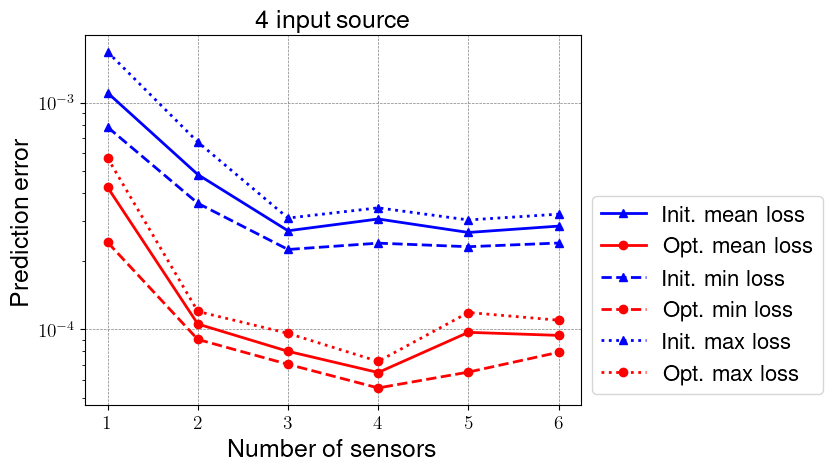

In [48]:
from matplotlib.ticker import MaxNLocator
init_loss_stat = jnp.zeros_like(init_loss_array)
opt_loss_stat = jnp.zeros_like(opt_loss_array)

init_loss_stat = init_loss_stat.at[:,0].set(jnp.mean( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,0].set(jnp.mean( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,1].set(jnp.min( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,1].set(jnp.min( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,2].set(jnp.max( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,2].set(jnp.max( opt_loss_array, axis=1 ))

fig, ax = plt.subplots()
marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
label_list = ["mean","min","max"]
N = init_loss_array.shape[0]

for i in range(3):
    plt.plot( jnp.arange(1,N+1), init_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[0], color="b", label="Init. " + label_list[i] + " loss" )
    plt.plot( jnp.arange(1,N+1), opt_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[1], color="r", label="Opt. " + label_list[i] + " loss" )
# plt.axhline(y=opt_loss_array[0], color='gray', linestyle='-.', label='Reference Line')
# plt.axhline(y=opt_loss_array[1], color='gray', linestyle='-.', label='Reference Line 2')
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.yscale("log")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("4 input source")
plt.xlabel("Number of sensors")
plt.ylabel("Prediction error")
plt.show()

In [ ]:

def load_and_plot(path, color, label, ax, show=True):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    if show:
        ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
        print(label)
        print(f"initial loss : {loss[0]:.4e}")
        print(f"minimum loss : {loss.min():.4e}")

    # min_idx = jnp.argmin( loss )
    # nn_record = record["nn_record"]
    # init_data = nn_record[0][2:6]
    # opt_data = nn_record[min_idx][2:6]
    # in_param_record = []

    # for i in range(100):
    #     in_param_record.append( nn_record[i][0:2] )
    # record_dict_2 = {"outer_iter": record["outer_iter"],
    #                 "inner_iter": record["inner_iter"],
    #                 "outer_lr": record["outer_lr"],
    #                 "inner_lr": record["inner_lr"],
    #                 "design_record": record["design_record"],
    #                 "nn_record": in_param_record,
    #                 "loss_record": record["loss_record"],
    #                 "initial_data": init_data,
    #                 "optimal_data": opt_data}
                    
    # with open(path, "wb") as f:
    #     pickle.dump(record_dict_2, f)

    return loss[0], loss.min()
    
init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs_set = [
    [([(38,)],              ["01062026"], 0),
    ([(27,)],               ["01142026"], 0),
    ([(49,)],               ["01142026"], 0),
    ([(24,)],               ["01232026"], 0),
    ([(30,)],               ["01232026"], 0)], # 1 sensor
    [([(25,29)],            ["01062026"], 1),
    ([(24,41)],             ["01162026"], 1),
    ([(35,30)],             ["01162026"], 1),
    ([(13,30)],             ["01232026"], 1),
    ([(19,35)],             ["01232026"], 1)], # 2 sensors
    [([(25,29,38)],         ["01062026"], 2),
    ([(27,35,41)],          ["01162026"], 2),
    ([(24,30,38)],          ["01162026"], 2),
    ([(19,27,35)],          ["01232026"], 2),
    ([(13,27,41)],          ["01232026"], 2)], # 3 sensors
    [([(26,28,35,41)],      ["01062026"], 3),
    ([(24,30,37,39)],       ["01162026"], 3),
    ([(26,28,41,46)],       ["01162026"], 3),
    ([(15,17,37,39)],       ["01262026"], 3),
    ([(25,29,47,51)],       ["01252026"], 3)], # 4 sensors
    [([(25,29,34,38,42)],   ["01062026"], 4),
    ([(23,27,31,36,40)],    ["01162026"], 4),
    ([(23,25,27,29,31)],    ["01162026"], 4),
    ([(24,30,35,38,41)],    ["01252026"], 4),
    ([(13,27,30,39,46)],    ["01262026"], 4)], # 5 sensors
    [([(13,16,19,35,38,41)], ["01062026"], 5),
    ([(24,27,30,36,39,42)], ["01162026"], 5),
    ([(24,27,30,47,50,53)], ["01162026"], 5),
    ([(14,18,25,29,36,40)], ["01252026"], 5),
    ([(25,29,36,40,47,51)], ["01252026"], 5)] # 6 sensors
]


for m in range(len(configs_set)):
    configs = configs_set[m]
    init_temp, opt_temp = [], []
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            if len(idx_tuple) == 1:
                idx_str = str(idx_tuple[0])
            else:
                idx_str = ",".join(str(x) for x in idx_tuple)

            if len(idx_tuple) == 1:
                file_idx = str(idx_tuple[0])
            else:
                file_idx = "_".join(str(x) for x in idx_tuple)

            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
            
            init, opt = load_and_plot(fname, color_list[k], idx_str, ax)
            init_temp.append(init)
            opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
    plt.show()
print(init_loss_set)
print(opt_loss_set)

In [6]:

path = "cooptimization_sim_1DCNN_data_300_n_source_4_all_locations.pickle"
with open(path, "rb") as f:
    record_dict = pickle.load(f)

init_loss_array = record_dict["init loss"]
opt_loss_array = record_dict["opt loss"]
N = init_loss_array.shape[0]
num_samples = init_loss_array.shape[1]  # Number of samples per sensor (should be 5)

# Prepare data for violin plots
# We need to create separate arrays for each sensor count
positions = jnp.arange(1, N + 1)  # x-axis positions (1, 2, 3, ..., N)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


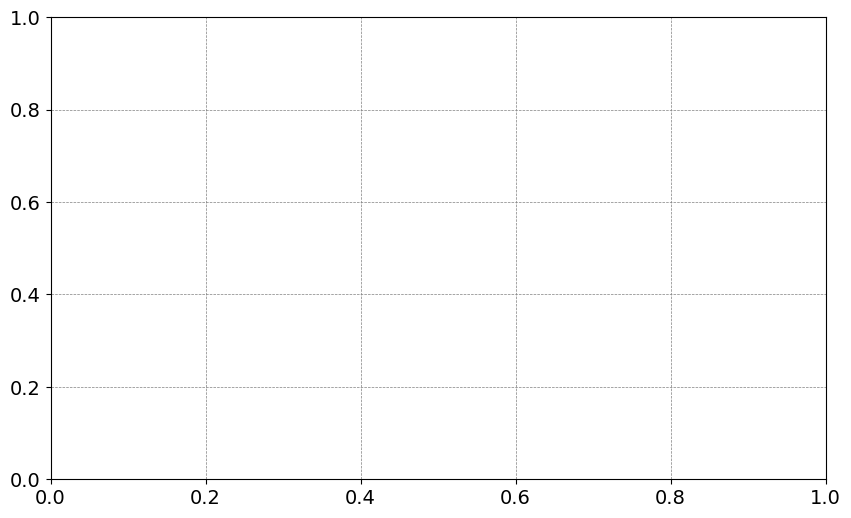

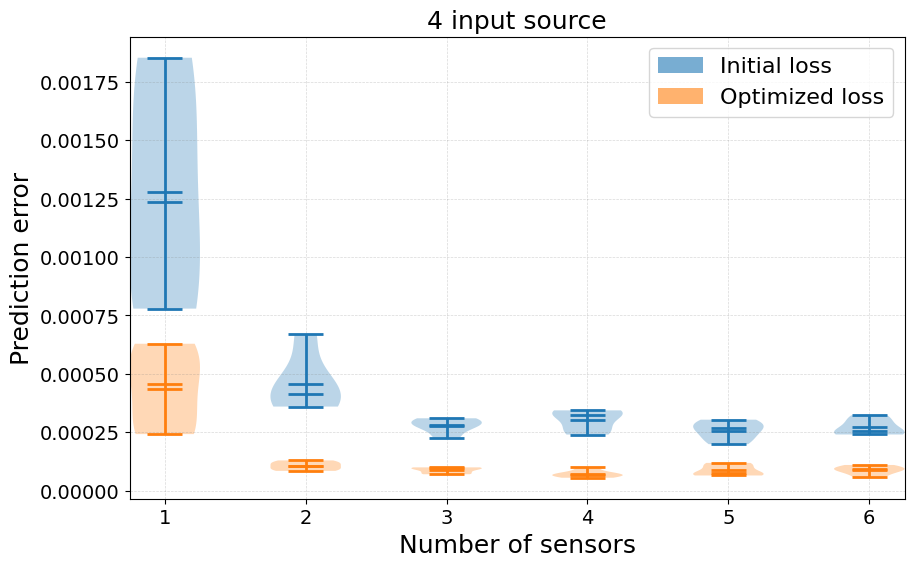

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plots
# For each sensor count, we have 5 values for init_loss and 5 for opt_loss
init_data = [init_loss_array[i, :] for i in range(N)]
opt_data = [opt_loss_array[i, :] for i in range(N)]

# Create violin plots
# We'll offset the positions slightly so the violins don't overlap
width = 0.35
init_positions = positions - width/2
opt_positions = positions + width/2

# Create violin plots
parts1 = ax.violinplot(init_data,
                       showmeans=True, showmedians=True)
parts2 = ax.violinplot(opt_data,
                       showmeans=True, showmedians=True)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
# ax.set_yscale('log')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.6, label='Initial loss'),
    Patch(facecolor='tab:orange', alpha=0.6, label='Optimized loss')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3)
ax.set_title("4 input source")
plt.savefig("Figure/4_input_source_loss_distribution_violin.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


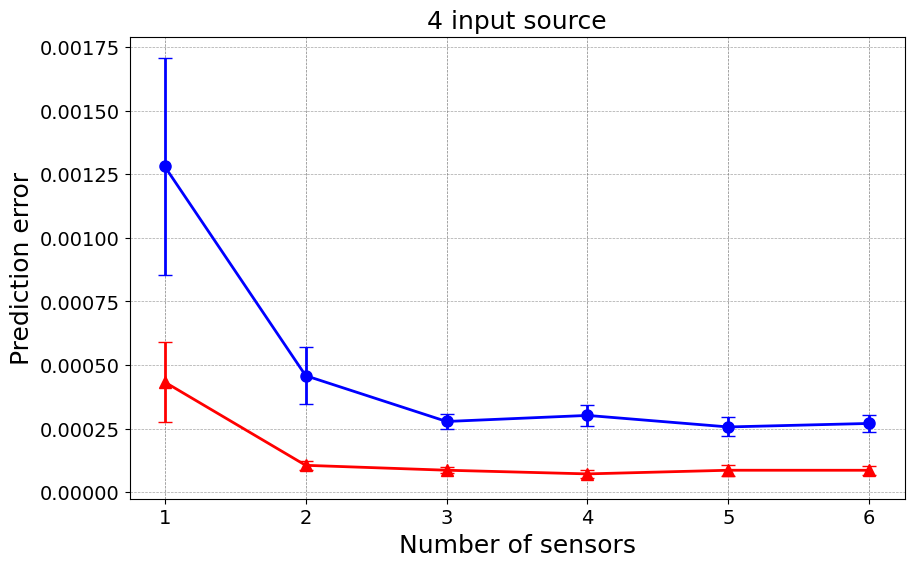

In [34]:
from matplotlib.ticker import MaxNLocator
init_mean = jnp.mean(init_loss_array, axis=1)
opt_mean = jnp.mean(opt_loss_array, axis=1)
init_std = jnp.std(init_loss_array, axis=1)
opt_std = jnp.std(opt_loss_array, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
plt.errorbar(jnp.arange(1,N+1), init_mean, yerr=init_std, fmt='o', markersize=8, capsize=5, 
             linestyle='-', color='b', ecolor='b')
plt.errorbar(jnp.arange(1,N+1), opt_mean, yerr=opt_std, fmt='^', markersize=8, capsize=5, 
             linestyle='-', color='r', ecolor='r')
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
ax.set_title("4 input source")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.yscale("log")
plt.savefig("Figure/4_input_source_loss_distribution.eps")
plt.show()

In [7]:
init_mean = jnp.mean(init_loss_array, axis=1)
opt_mean = jnp.mean(opt_loss_array, axis=1)
init_std = jnp.std(init_loss_array, axis=1)
opt_std = jnp.std(opt_loss_array, axis=1)

print( init_mean )
print("==================")
print( opt_mean )
print("==================")
print( jnp.array(opt_mean) / jnp.array(init_mean) )

[0.00128029 0.00045838 0.00027838 0.00030222 0.00025689 0.00027069]
[4.33109599e-04 1.06120286e-04 8.68652165e-05 7.24302201e-05
 8.67806342e-05 8.66618637e-05]
[0.33828939 0.2315106  0.31203692 0.23966134 0.33781844 0.32014652]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


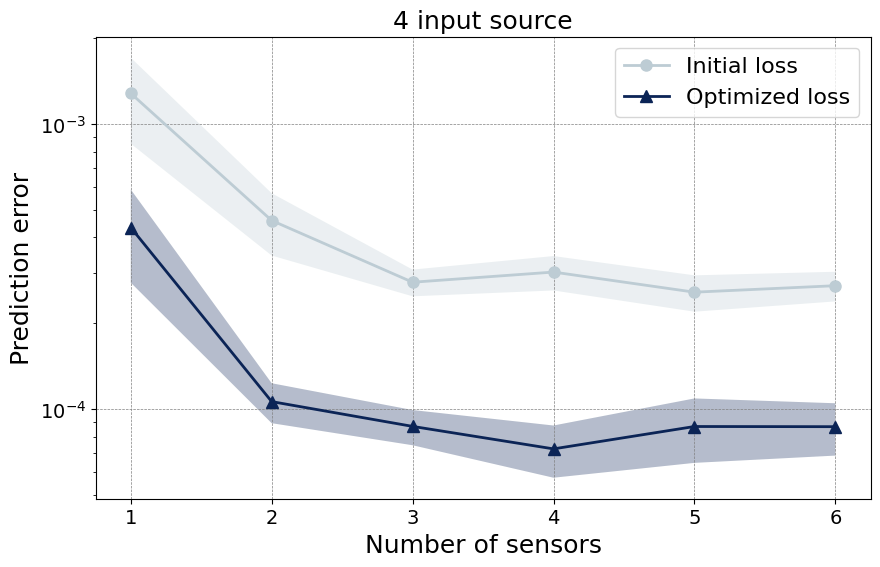

In [16]:
from matplotlib.ticker import MaxNLocator
init_mean = jnp.mean(init_loss_array, axis=1)
opt_mean = jnp.mean(opt_loss_array, axis=1)
init_std = jnp.std(init_loss_array, axis=1)
opt_std = jnp.std(opt_loss_array, axis=1)

# fig, ax = plt.subplots(figsize=(25, 4))
# ax.plot(jnp.arange(1,N+1), init_mean, linewidth=1, c="b", marker="o", markersize=15, label="Initial loss")
# ax.fill_between(jnp.arange(1,N+1), init_mean-init_std, init_mean+init_std, alpha=0.3, facecolor="b")
# ax.plot(jnp.arange(1,N+1), opt_mean, linewidth=1, c="r", marker="^", markersize=15, label="Optimized loss")
# ax.fill_between(jnp.arange(1,N+1), opt_mean-opt_std, opt_mean+opt_std ,alpha=0.3, facecolor="r")
# ax.set_xlabel("Number of sensors")
# ax.set_ylabel("Prediction error")
# ax.set_title("4 input source")
# ax.margins(x=0.05) 
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.legend()
# # ax.set_ylim(0.0, 0.0025)
# # ax.set_yscale('log')
# plt.savefig("Figure/4_input_source_loss_distribution_error_bar_colored_no_ylim_longer_2.eps")
# plt.show()

color_list = ["#bdccd4", "#0b2456"] # gray, dark blue
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(jnp.arange(1,N+1), init_mean, c=color_list[0], marker="o", markersize=8, label="Initial loss")
ax.fill_between(jnp.arange(1,N+1), init_mean-init_std, init_mean+init_std ,alpha=0.3, facecolor=color_list[0])
ax.plot(jnp.arange(1,N+1), opt_mean, c=color_list[1], marker="^", markersize=8, label="Optimized loss")
ax.fill_between(jnp.arange(1,N+1), opt_mean-opt_std, opt_mean+opt_std ,alpha=0.3, facecolor=color_list[1])
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
ax.set_title("4 input source")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend()
ax.set_yscale('log')
# ax.set_ylim(0.0, 0.0025)
plt.savefig("Figure/4_input_source_loss_distribution_error_bar_colored_log.eps")
plt.savefig("Figure/4_input_source_loss_distribution_error_bar_colored_log.png")
plt.show()

In [ ]:
record_dict = {
    "init loss": jnp.array(init_loss_set),
    "opt loss": jnp.array(opt_loss_set)
}
path = "cooptimization_sim_1DCNN_data_300_n_source_4_all_locations.pickle"
with open(path, "xb") as f:
    pickle.dump(record_dict, f)

## 8 input source with different positions

In [ ]:

def load_and_plot(path, color, label, ax, show=True):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    if show:
        ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
        print(label)
        print(f"initial loss : {loss[0]:.4e}")
        print(f"minimum loss : {loss.min():.4e}")
    
    return loss[0], loss.min()
    
init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs_set = [
    [([(57,)],              ["01062026"], 0),
    ([(52,)],              ["01162026"], 1),
    ([(53,)],              ["01172026"], 2)], # 1 sensor
    [([(52,62)],            ["01062026"], 1),
    ([(75,62)],            ["01172026"], 1),
    ([(75,85)],            ["01172026"], 1)], # 2 sensors
    [([(52,57,62)],         ["01062026"], 2),
    ([(52,80,108)],         ["01172026"], 2),
    ([(57,75,85)],         ["01172026"], 2)], # 3 sensors
    [([(49,55,60,65)],      ["01062026"], 3),
    ([(72,78,83,88)],      ["01182026"], 3),
    ([(55,60,75,85)],      ["01182026"], 3)], # 4 sensors
    [([(49,53,57,61,65)],   ["01062026"], 4),
    ([(72,76,80,84,88)],   ["01162026"], 4),
    ([(49,57,65,76,84)],   ["01172026"], 4)], # 5 sensors
    [([(28,34,40,97,103,109)], ["01072026"], 5),
    ([(49,56,63,97,104,111)], ["01172026"], 5),
    ([(49,54,59,63,98,106)], ["01172026"], 5)] # 6 sensors
]


for m in range(len(configs_set)):
    configs = configs_set[m]
    init_temp, opt_temp = [], []
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            if len(idx_tuple) == 1:
                idx_str = str(idx_tuple[0])
            else:
                idx_str = ",".join(str(x) for x in idx_tuple)

            if len(idx_tuple) == 1:
                file_idx = str(idx_tuple[0])
            else:
                file_idx = "_".join(str(x) for x in idx_tuple)

            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
            
            init, opt = load_and_plot(fname, color_list[k], idx_str, ax)
            init_temp.append(init)
            opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
    plt.show()
print(init_loss_set)
print(opt_loss_set)

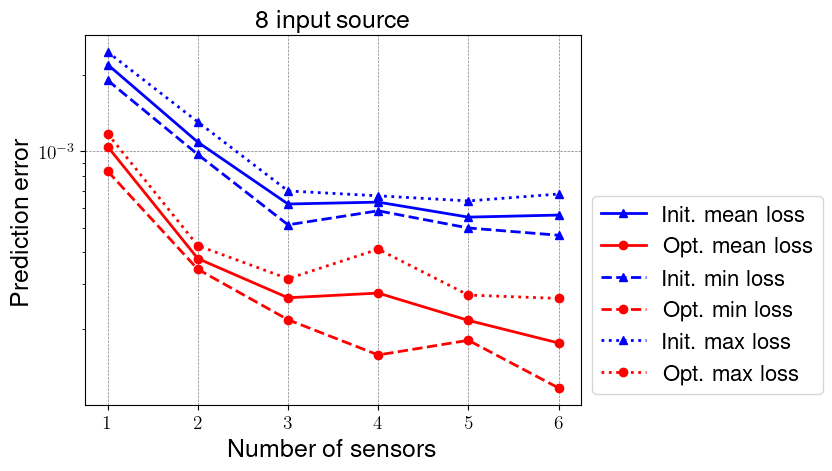

In [57]:
from matplotlib.ticker import MaxNLocator
init_loss_array = jnp.array( init_loss_set ).copy()
opt_loss_array = jnp.array( opt_loss_set ).copy()

init_loss_stat = jnp.zeros_like(init_loss_array)
opt_loss_stat = jnp.zeros_like(opt_loss_array)

init_loss_stat = init_loss_stat.at[:,0].set(jnp.mean( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,0].set(jnp.mean( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,1].set(jnp.min( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,1].set(jnp.min( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,2].set(jnp.max( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,2].set(jnp.max( opt_loss_array, axis=1 ))

fig, ax = plt.subplots()
marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
label_list = ["mean","min","max"]
N = init_loss_array.shape[0]

for i in range(3):
    plt.plot( jnp.arange(1,N+1), init_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[0], color="b", label="Init. " + label_list[i] + " loss" )
    plt.plot( jnp.arange(1,N+1), opt_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[1], color="r", label="Opt. " + label_list[i] + " loss" )
# plt.axhline(y=opt_loss_array[0], color='gray', linestyle='-.', label='Reference Line')
# plt.axhline(y=opt_loss_array[1], color='gray', linestyle='-.', label='Reference Line 2')
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.yscale("log")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("8 input source")
plt.xlabel("Number of sensors")
plt.ylabel("Prediction error")
plt.show()

In [54]:
record_dict = {
    "init loss": jnp.array(init_loss_set),
    "opt loss": jnp.array(opt_loss_set)
}
path = "cooptimization_sim_1DCNN_data_300_n_source_8_all_locations.pickle"
with open(path, "wb") as f:
    pickle.dump(record_dict, f)

57
initial loss : 2.4686e-03
minimum loss : 1.1744e-03
62
initial loss : 2.7726e-03
minimum loss : 1.5142e-03
53
initial loss : 1.9076e-03
minimum loss : 8.3608e-04
75
initial loss : 1.9514e-03
minimum loss : 8.4225e-04
80
initial loss : 1.9086e-03
minimum loss : 8.7367e-04


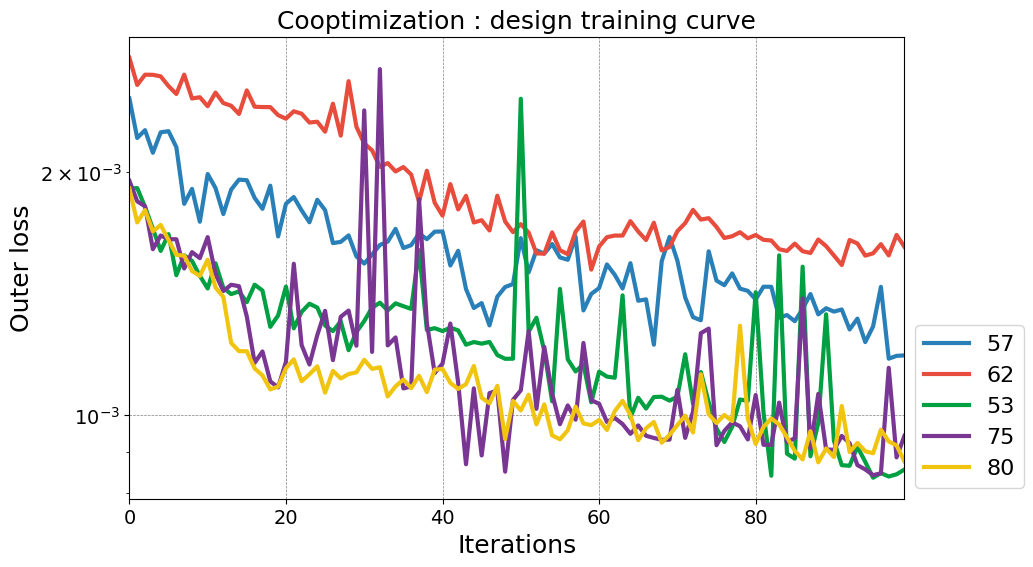

52,62
initial loss : 1.3074e-03
minimum loss : 4.2515e-04
75,62
initial loss : 9.7305e-04
minimum loss : 3.4294e-04
75,85
initial loss : 9.8405e-04
minimum loss : 3.6598e-04
77,83
initial loss : 7.1375e-04
minimum loss : 4.5056e-04
60,77
initial loss : 7.3803e-04
minimum loss : 3.8116e-04


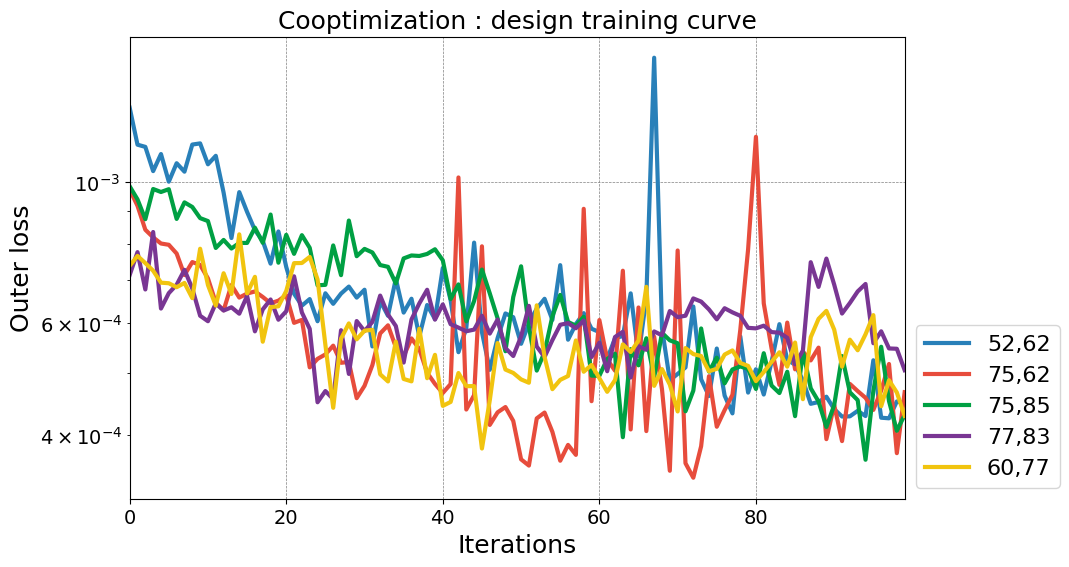

52,57,62
initial loss : 6.9852e-04
minimum loss : 3.1495e-04
52,80,108
initial loss : 6.4949e-04
minimum loss : 2.6270e-04
57,75,85
initial loss : 5.1365e-04
minimum loss : 2.1698e-04
49,65,80
initial loss : 8.6895e-04
minimum loss : 4.6318e-04
75,80,85
initial loss : 7.7410e-04
minimum loss : 3.0675e-04


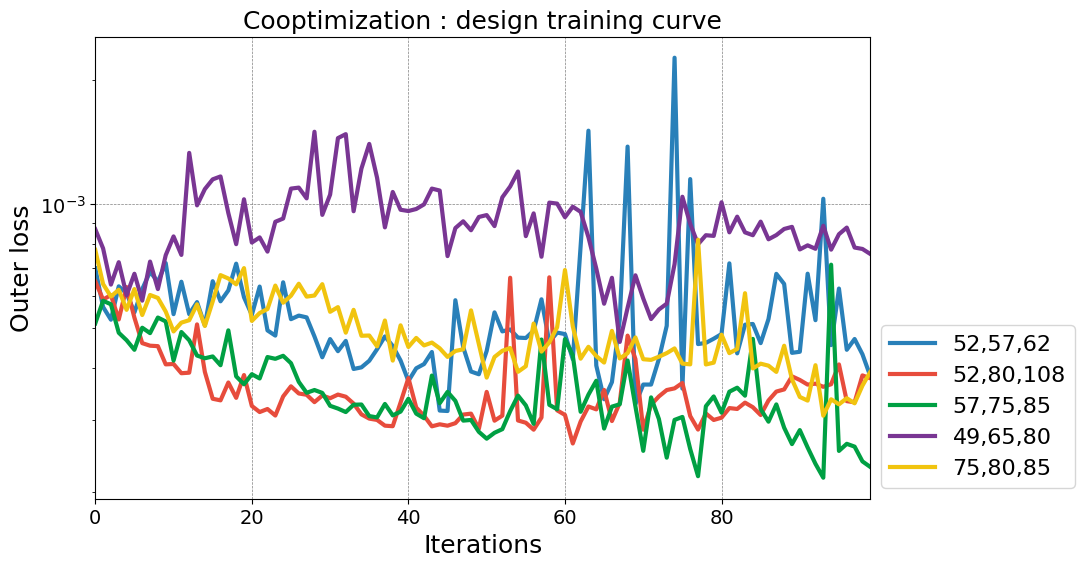

49,55,60,65
initial loss : 6.6849e-04
minimum loss : 2.5983e-04
55,60,75,85
initial loss : 6.4171e-04
minimum loss : 1.5756e-04
41,52,75,85
initial loss : 5.4223e-04
minimum loss : 1.8459e-04
41,52,77,83
initial loss : 5.4479e-04
minimum loss : 1.5479e-04
49,60,100,111
initial loss : 5.4633e-04
minimum loss : 2.2209e-04


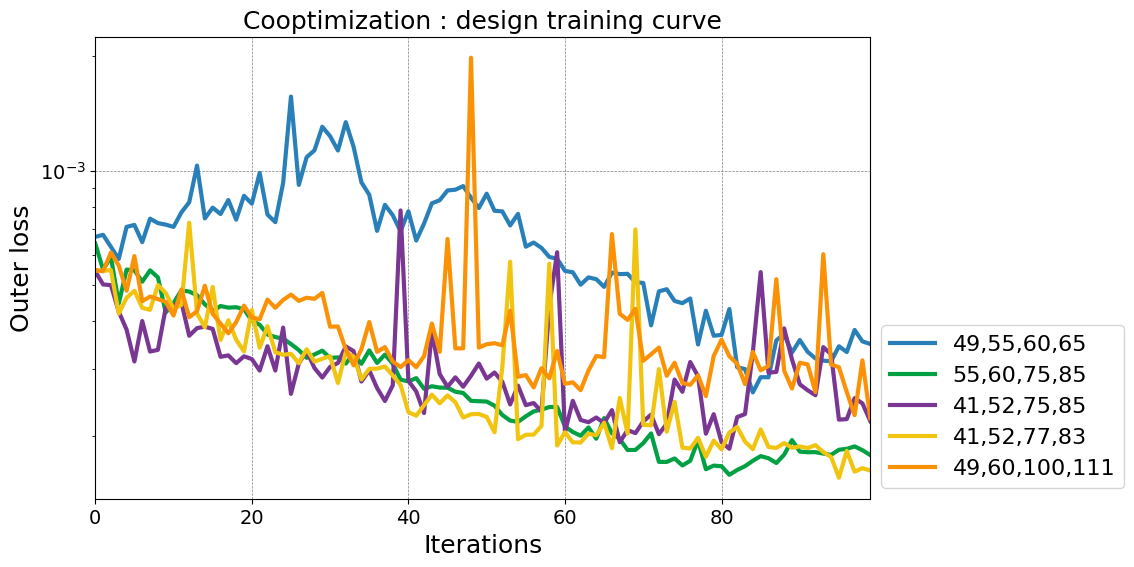

49,53,57,61,65
initial loss : 4.9913e-04
minimum loss : 1.9552e-04
72,76,80,84,88
initial loss : 5.1532e-04
minimum loss : 2.7140e-04
49,57,65,76,84
initial loss : 6.3805e-04
minimum loss : 1.8000e-04
53,61,74,86,103
initial loss : 5.4642e-04
minimum loss : 1.6044e-04
53,57,61,74,86
initial loss : 5.2165e-04
minimum loss : 2.0991e-04


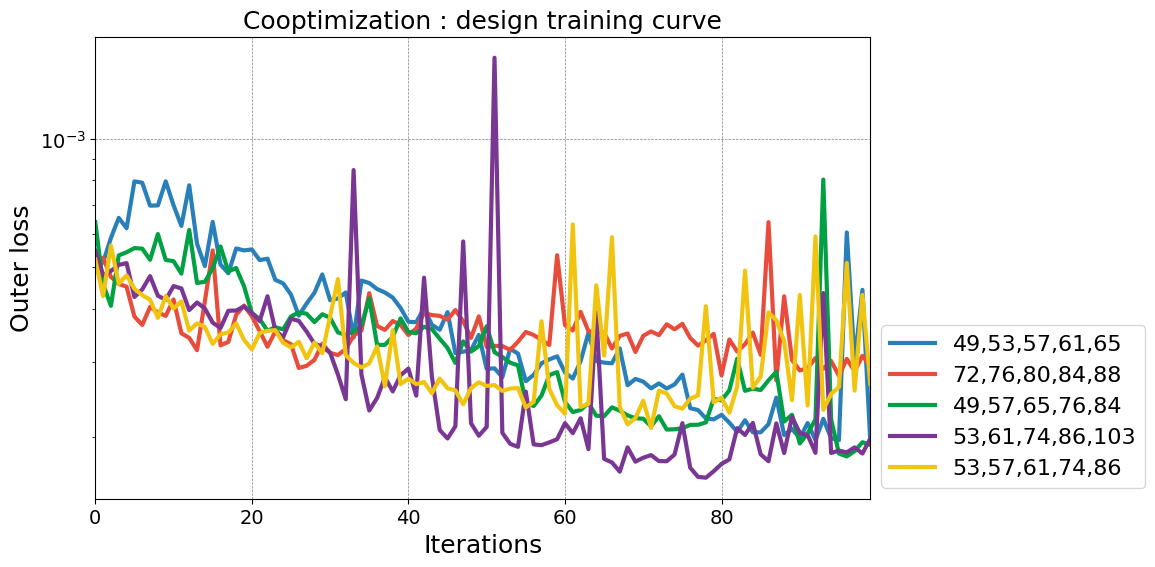

28,34,40,97,103,109
initial loss : 4.6728e-04
minimum loss : 1.1677e-04
49,56,63,97,104,111
initial loss : 6.7943e-04
minimum loss : 2.6328e-04
49,54,59,63,98,106
initial loss : 5.3696e-04
minimum loss : 1.4696e-04
51,55,59,63,79,84
initial loss : 3.6647e-04
minimum loss : 1.9300e-04
52,57,62,74,86,103
initial loss : 5.3170e-04
minimum loss : 2.1777e-04


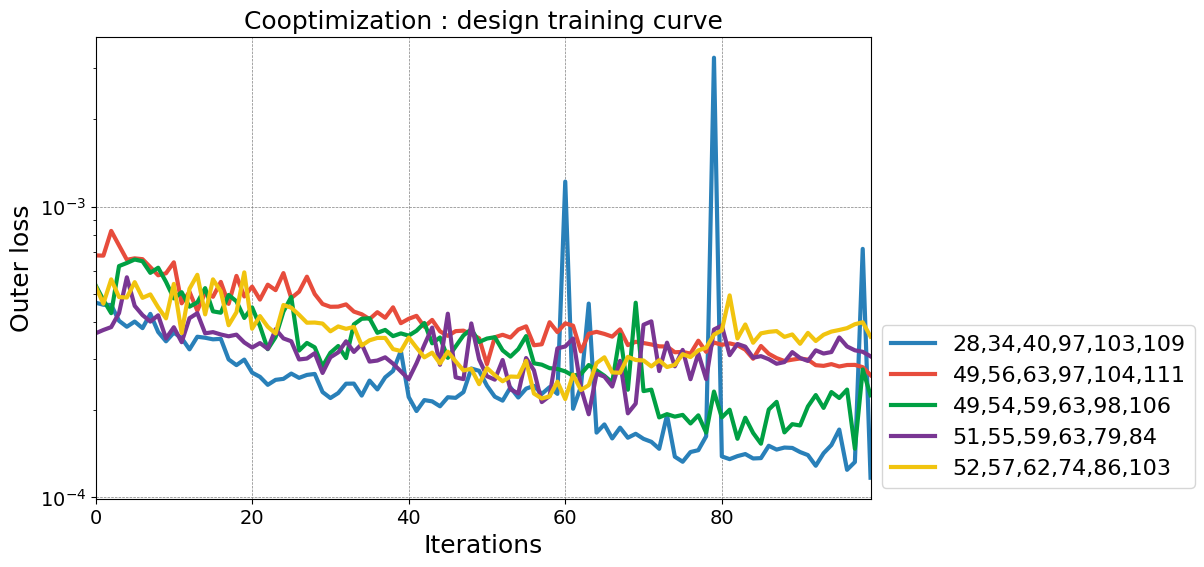

[Array([0.00246857, 0.00277264, 0.00190761, 0.00195137, 0.00190863],      dtype=float64), Array([0.00130744, 0.00097305, 0.00098405, 0.00071375, 0.00073803],      dtype=float64), Array([0.00069852, 0.00064949, 0.00051365, 0.00086895, 0.0007741 ],      dtype=float64), Array([0.00066849, 0.00064171, 0.00054223, 0.00054479, 0.00054633],      dtype=float64), Array([0.00049913, 0.00051532, 0.00063805, 0.00054642, 0.00052165],      dtype=float64), Array([0.00046728, 0.00067943, 0.00053696, 0.00036647, 0.0005317 ],      dtype=float64)]
[Array([0.00117442, 0.0015142 , 0.00083608, 0.00084225, 0.00087367],      dtype=float64), Array([0.00042515, 0.00034294, 0.00036598, 0.00045056, 0.00038116],      dtype=float64), Array([0.00031495, 0.0002627 , 0.00021698, 0.00046318, 0.00030675],      dtype=float64), Array([0.00025983, 0.00015756, 0.00018459, 0.00015479, 0.00022209],      dtype=float64), Array([0.00019552, 0.0002714 , 0.00018   , 0.00016044, 0.00020991],      dtype=float64), Array([0.00011677, 

In [8]:

def load_and_plot(path, color, label, ax, show=True):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])
    if show:
        ax.plot(jnp.arange(len(loss)), loss, color=color, lw=3, label=label)
        print(label)
        print(f"initial loss : {loss[0]:.4e}")
        print(f"minimum loss : {loss.min():.4e}")

    # min_idx = jnp.argmin( loss )
    # nn_record = record["nn_record"]
    # init_data = nn_record[0][2:6]
    # opt_data = nn_record[min_idx][2:6]
    # in_param_record = []

    # for i in range(100):
    #     in_param_record.append( nn_record[i][0:2] )
        
    # record_dict_2 = {"outer_iter": record["outer_iter"],
    #                 "inner_iter": record["inner_iter"],
    #                 "outer_lr": record["outer_lr"],
    #                 "inner_lr": record["inner_lr"],
    #                 "design_record": record["design_record"],
    #                 "nn_record": in_param_record,
    #                 "loss_record": record["loss_record"],
    #                 "initial_data": init_data,
    #                 "optimal_data": opt_data}
                    
    # with open(path, "wb") as f:
    #     pickle.dump(record_dict_2, f)

    return loss[0], loss.min()

color_list = ["#2980b9", "#e74c3c", "#00a043", "#793693", "#f1c40f","#fb9206","#54ada3","#c7c7c7"]
init_loss_set, opt_loss_set = [], []
# All sensor configs (idx tuples, corresponding date, color index for plot label)
configs_set = [
    [([(57,)],              ["01062026"], 0),
    ([(62,)],              ["01192026"], 1),
    ([(53,)],              ["01172026"], 2),
    ([(75,)],              ["01232026"], 3),
    ([(80,)],              ["01232026"], 4)], # 1 sensor
    [([(52,62)],            ["01062026"], 0),
    ([(75,62)],            ["01172026"], 1),
    ([(75,85)],            ["01172026"], 2),
    ([(77,83)],            ["01232026"], 3),
    ([(60,77)],            ["01242026"], 4)], # 2 sensors
    [([(52,57,62)],         ["01062026"], 0),
    ([(52,80,108)],         ["01172026"], 1),
    ([(57,75,85)],         ["01172026"], 2),
    ([(49,65,80)],         ["01242026"], 3),
    ([(75,80,85)],         ["01242026"], 4)], # 3 sensors
    [([(49,55,60,65)],      ["01062026"], 0),
    # ([(72,78,83,88)],      ["01182026"], 1),
    ([(55,60,75,85)],      ["01182026"], 2),
    ([(41,52,75,85)],      ["01242026"], 3),
    ([(41,52,77,83)],      ["01242026"], 4),
    ([(49,60,100,111)],     ["03042026"], 5)],
    # ([(52,62,98,108)],     ["03042026"], 6),
    # ([(74,86,96,106)],     ["03052026"], 7)], # 4 sensors
    [([(49,53,57,61,65)],   ["01062026"], 0),
    ([(72,76,80,84,88)],   ["01162026"], 1),
    ([(49,57,65,76,84)],   ["01172026"], 2),
    ([(53,61,74,86,103)],   ["01252026"], 3),
    ([(53,57,61,74,86)],   ["01252026"], 4)], # 5 sensors
    [([(28,34,40,97,103,109)], ["01072026"], 0),
    ([(49,56,63,97,104,111)], ["01172026"], 1),
    ([(49,54,59,63,98,106)], ["01172026"], 2),
    ([(51,55,59,63,79,84)], ["01242026"], 3),
    ([(52,57,62,74,86,103)], ["01242026"], 4) ] # 6 sensors
]


for m in range(len(configs_set)):
    configs = configs_set[m]
    init_temp, opt_temp = [], []
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            if len(idx_tuple) == 1:
                idx_str = str(idx_tuple[0])
            else:
                idx_str = ",".join(str(x) for x in idx_tuple)

            if len(idx_tuple) == 1:
                file_idx = str(idx_tuple[0])
            else:
                file_idx = "_".join(str(x) for x in idx_tuple)

            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
            
            init, opt = load_and_plot(fname, color_list[k], idx_str, ax)
            init_temp.append(init)
            opt_temp.append(opt)
    init_loss_set.append(jnp.array(init_temp))
    opt_loss_set.append(jnp.array(opt_temp))
    plt.title('Cooptimization : design training curve')
    plt.yscale('log')
    plt.ylabel("Outer loss")
    plt.xlabel("Iterations")
    plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
    plt.show()
print(init_loss_set)
print(opt_loss_set)

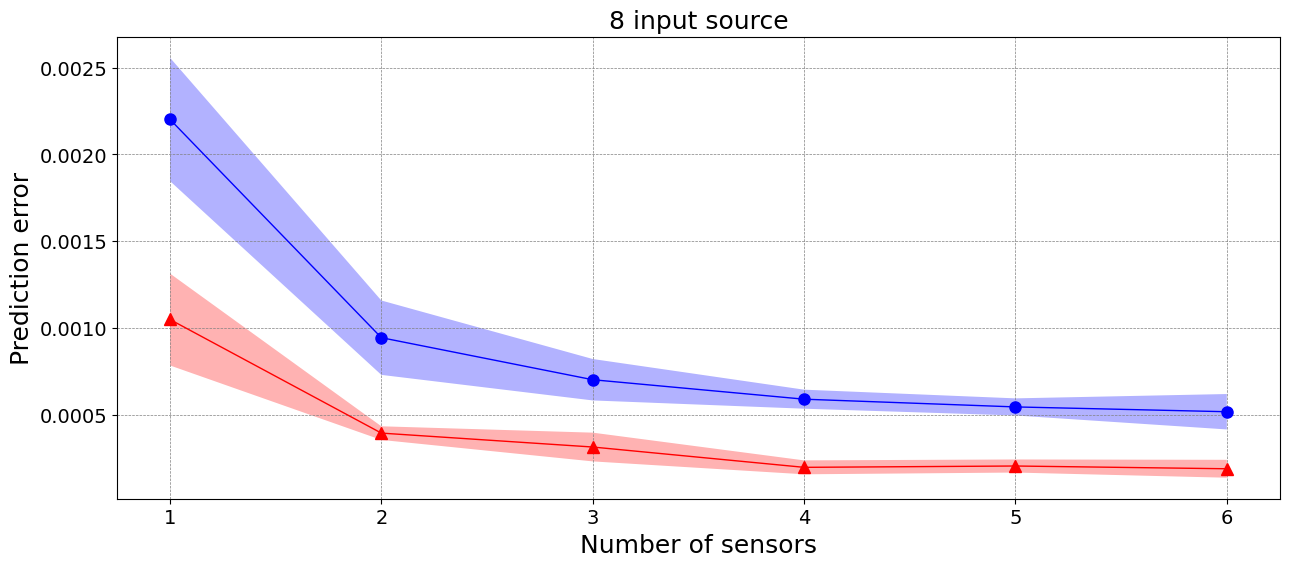

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


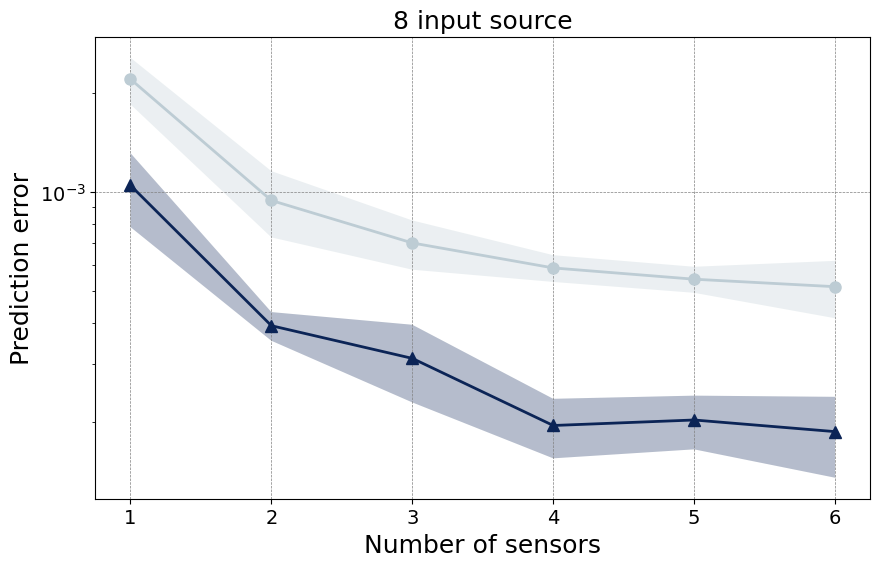

In [17]:
from matplotlib.ticker import MaxNLocator

init_mean = []
opt_mean = []
init_std = []
opt_std = []

N = 6
for i in range(len(init_loss_set)):
    init_mean.append(jnp.mean(init_loss_set[i]))
    opt_mean.append(jnp.mean(opt_loss_set[i]))
    init_std.append(jnp.std(init_loss_set[i]))
    opt_std.append(jnp.std(opt_loss_set[i]))

init_mean = jnp.array(init_mean)
opt_mean = jnp.array(opt_mean)
init_std = jnp.array(init_std)
opt_std = jnp.array(opt_std)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(jnp.arange(1,N+1), init_mean, c="b", marker="o", linewidth=1, markersize=8, label="Initial loss")
ax.fill_between(jnp.arange(1,N+1), init_mean-init_std, init_mean+init_std ,alpha=0.3, facecolor="b")
ax.plot(jnp.arange(1,N+1), opt_mean, c="r", marker="^", linewidth=1,markersize=8, label="Optimized loss")
ax.fill_between(jnp.arange(1,N+1), opt_mean-opt_std, opt_mean+opt_std ,alpha=0.3, facecolor="r")
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
ax.set_title("8 input source")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.legend()
# ax.set_yscale('log')
# ax.set_ylim(0.0, 0.0025)
# plt.savefig("Figure/8_input_source_loss_distribution_error_bar_colored.eps")
plt.show()

color_list = ["#bdccd4", "#0b2456"] # gray, dark blue
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(jnp.arange(1,N+1), init_mean, c=color_list[0], marker="o", markersize=8, label="Initial loss")
ax.fill_between(jnp.arange(1,N+1), init_mean-init_std, init_mean+init_std ,alpha=0.3, facecolor=color_list[0])
ax.plot(jnp.arange(1,N+1), opt_mean, c=color_list[1], marker="^", markersize=8, label="Optimized loss")
ax.fill_between(jnp.arange(1,N+1), opt_mean-opt_std, opt_mean+opt_std ,alpha=0.3, facecolor=color_list[1])
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
ax.set_title("8 input source")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.legend()
ax.set_yscale('log')
# ax.set_ylim(0.0, 0.0025)
plt.savefig("Figure/8_input_source_loss_distribution_error_bar_colored_log.eps")
plt.savefig("Figure/8_input_source_loss_distribution_error_bar_colored_log.png")
plt.show()

In [8]:

path = "cooptimization_sim_1DCNN_data_300_n_source_8_all_locations.pickle"
with open(path, "rb") as f:
    record_dict = pickle.load(f)

init_loss_array = record_dict["init loss"]
opt_loss_array = record_dict["opt loss"]
N = init_loss_array.shape[0]
num_samples = init_loss_array.shape[1]  # Number of samples per sensor (should be 5)

# Prepare data for violin plots
# We need to create separate arrays for each sensor count
positions = jnp.arange(1, N + 1)  # x-axis positions (1, 2, 3, ..., N)

In [9]:
init_mean = jnp.mean(init_loss_array, axis=1)
opt_mean = jnp.mean(opt_loss_array, axis=1)
init_std = jnp.std(init_loss_array, axis=1)
opt_std = jnp.std(opt_loss_array, axis=1)

print( init_mean )
print("==================")
print( opt_mean )
print("==================")
print( opt_mean / init_mean )

[0.00220176 0.00094326 0.00070094 0.00058871 0.00054411 0.00051637]
[0.00104813 0.00039316 0.00031291 0.00019577 0.00020345 0.00018756]
[0.47603899 0.4168042  0.44641331 0.33254239 0.37391574 0.36322483]


In [12]:
record_dict = {
    "init loss": jnp.array(init_loss_set),
    "opt loss": jnp.array(opt_loss_set)
}

path = "cooptimization_sim_1DCNN_data_300_n_source_8_all_locations.pickle"
with open(path, "wb") as f:
    pickle.dump(record_dict, f)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


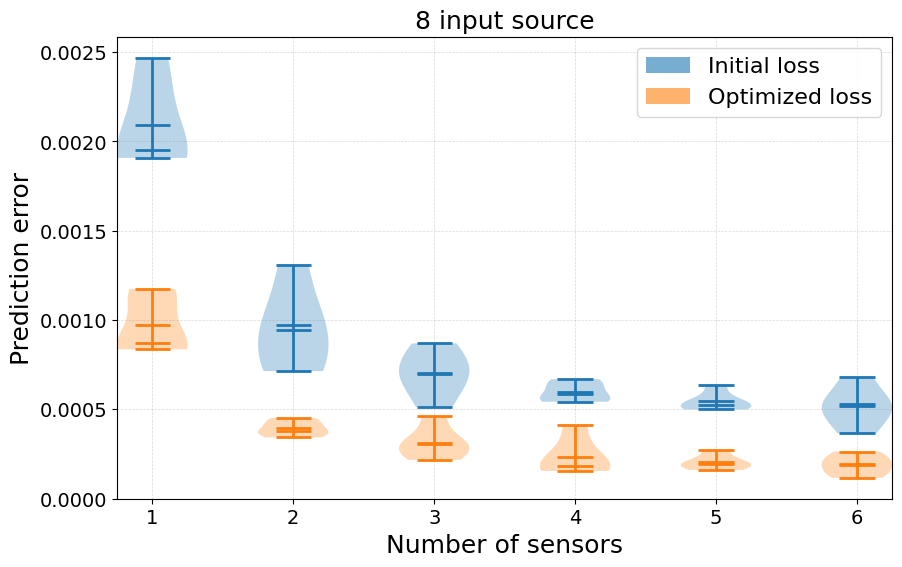

In [22]:
# Violin plots for init_loss and opt_loss distributions
import numpy as np
from matplotlib.ticker import MaxNLocator


# Convert JAX arrays to numpy for plotting
init_loss_np = np.array(init_loss_array)
opt_loss_np = np.array(opt_loss_array)

N = init_loss_np.shape[0]  # Number of sensors
num_samples = init_loss_np.shape[1]  # Number of samples per sensor (should be 5)

# Prepare data for violin plots
# We need to create separate arrays for each sensor count
positions = np.arange(1, N + 1)  # x-axis positions (1, 2, 3, ..., N)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plots
# For each sensor count, we have 5 values for init_loss and 5 for opt_loss
init_data = [init_loss_np[i, :] for i in range(N)]
opt_data = [opt_loss_np[i, :] for i in range(N)]

# Create violin plots
# We'll offset the positions slightly so the violins don't overlap
width = 0.35
init_positions = positions - width/2
opt_positions = positions + width/2

# Create violin plots
parts1 = ax.violinplot(init_data,
                       showmeans=True, showmedians=True)
parts2 = ax.violinplot(opt_data,
                       showmeans=True, showmedians=True)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
# ax.set_yscale('log')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.6, label='Initial loss'),
    Patch(facecolor='tab:orange', alpha=0.6, label='Optimized loss')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3)
ax.set_title("8 input source")
plt.savefig("Figure/8_input_source_loss_distribution_violin.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


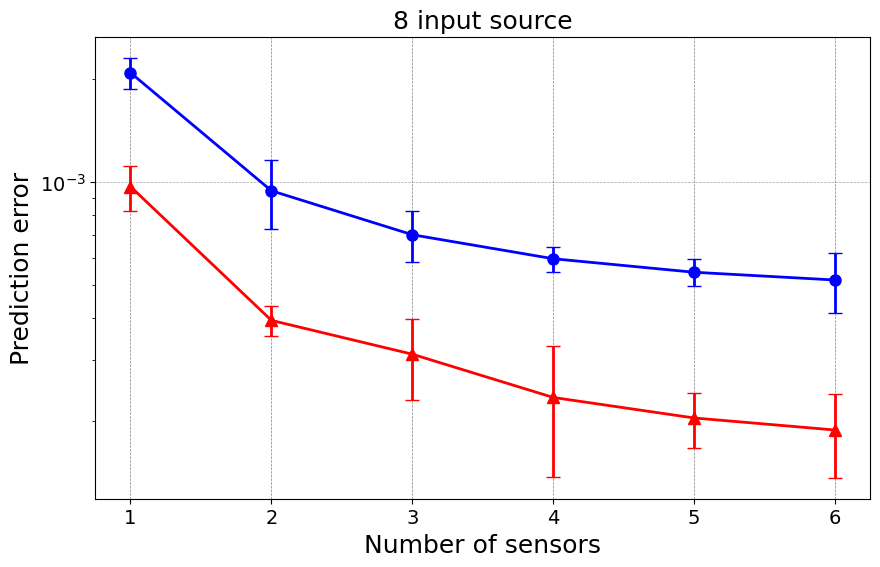

In [24]:
from matplotlib.ticker import MaxNLocator
init_mean = jnp.mean(init_loss_array, axis=1)
opt_mean = jnp.mean(opt_loss_array, axis=1)
init_std = jnp.std(init_loss_array, axis=1)
opt_std = jnp.std(opt_loss_array, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
plt.errorbar(jnp.arange(1,N+1), init_mean, yerr=init_std, fmt='o', markersize=8, capsize=5, 
             linestyle='-', color='b', ecolor='b')
plt.errorbar(jnp.arange(1,N+1), opt_mean, yerr=opt_std, fmt='^', markersize=8, capsize=5, 
             linestyle='-', color='r', ecolor='r')
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Prediction error")
ax.set_title("8 input source")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale("log")
plt.savefig("Figure/8_input_source_loss_distribution_log.eps")
plt.show()

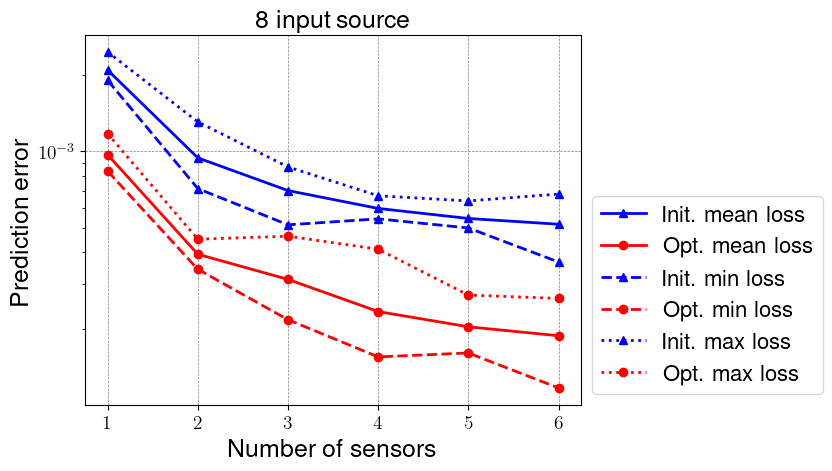

In [12]:
from matplotlib.ticker import MaxNLocator
init_loss_array = jnp.array( init_loss_set ).copy()
opt_loss_array = jnp.array( opt_loss_set ).copy()

init_loss_stat = jnp.zeros_like(init_loss_array)
opt_loss_stat = jnp.zeros_like(opt_loss_array)

init_loss_stat = init_loss_stat.at[:,0].set(jnp.mean( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,0].set(jnp.mean( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,1].set(jnp.min( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,1].set(jnp.min( opt_loss_array, axis=1 ))
init_loss_stat = init_loss_stat.at[:,2].set(jnp.max( init_loss_array, axis=1 ))
opt_loss_stat = opt_loss_stat.at[:,2].set(jnp.max( opt_loss_array, axis=1 ))

fig, ax = plt.subplots()
marker_list = ["^","o","s"]
linestyle_list = ["-","--",":"]
label_list = ["mean","min","max"]
N = init_loss_array.shape[0]

for i in range(3):
    plt.plot( jnp.arange(1,N+1), init_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[0], color="b", label="Init. " + label_list[i] + " loss" )
    plt.plot( jnp.arange(1,N+1), opt_loss_stat[:,i], linestyle=linestyle_list[i], marker=marker_list[1], color="r", label="Opt. " + label_list[i] + " loss" )
# plt.axhline(y=opt_loss_array[0], color='gray', linestyle='-.', label='Reference Line')
# plt.axhline(y=opt_loss_array[1], color='gray', linestyle='-.', label='Reference Line 2')
plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.0))
plt.yscale("log")
ax.margins(x=0.05) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("8 input source")
plt.xlabel("Number of sensors")
plt.ylabel("Prediction error")
plt.show()